## Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
print('Numpy Version',np.__version__)
print('Pandas Version',pd.__version__)
print('Seaborn Version',sns.__version__)
print('Matplotlib Version',matplotlib.__version__)

Numpy Version 2.0.2
Pandas Version 2.2.2
Seaborn Version 0.13.2
Matplotlib Version 3.10.0


## Importing dataset

In [ ]:
CC = pd.read_excel("/content/LoyaltyVision Analytics (1).xlsx")
CC.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile


### Shape of dataset

In [ ]:
## Shape of dataset
CC.shape

(11260, 19)

In [ ]:
CC.size

213940

In [ ]:
## High level information
CC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

### Describing dataset

In [ ]:
CC.describe()

,AccountID,Churn,City_Tier,CC_Contacted_LY,Service_Score,CC_Agent_Score,Complain_ly
count,11260.00000,11260.000000,11148.000000,11158.000000,11162.000000,11144.000000,10903.000000
mean,25629.50000,0.168384,1.653929,17.867091,2.902526,3.066493,0.285334
std,3250.62635,0.374223,0.915015,8.853269,0.725584,1.379772,0.451594
min,20000.00000,0.000000,1.000000,4.000000,0.000000,1.000000,0.000000
25%,22814.75000,0.000000,1.000000,11.000000,2.000000,2.000000,0.000000
50%,25629.50000,0.000000,1.000000,16.000000,3.000000,3.000000,0.000000
75%,28444.25000,0.000000,3.000000,23.000000,3.000000,4.000000,1.000000
max,31259.00000,1.000000,3.000000,132.000000,5.000000,5.000000,1.000000


### Checking duplicates

In [ ]:
CC.duplicated().sum()

np.int64(0)

### Checking Null Values

In [ ]:
CC.isnull().sum()

,0
AccountID,0
Churn,0
Tenure,102
City_Tier,112
CC_Contacted_LY,102
Payment,109
Gender,108
Service_Score,98
Account_user_count,112
account_segment,97


In [ ]:
## Proportion of nulls in predictors out of total size of the predictor dataset expressed as percentage
CC_predictor = CC.drop(['AccountID','Churn'],axis=1)

round(((CC_predictor.isnull().sum().sum()/ CC_predictor.size) * 100 ),2)

np.float64(1.4)

In [ ]:
## Nulls by rows

CC_predictor.isnull().sum(axis = 1)

,0
0,0
1,0
2,1
3,0
4,0
...,...
11255,0
11256,0
11257,0
11258,0


In [ ]:
CC_predictor_temp = CC_predictor[CC_predictor.isnull().sum(axis = 1) >= 3]
CC_predictor_temp

,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device


In [ ]:
CC_predictor_temp = CC_predictor[CC_predictor.isnull().sum(axis = 1) == 2]
CC_predictor_temp.shape

(121, 17)

In [ ]:
## Percentage nulls by column in predictor dataset
round((CC_predictor.isnull().sum().sort_values(ascending = False)/CC_predictor.index.size ) * 100, 2)

,0
cashback,4.18
Day_Since_CC_connect,3.17
Complain_ly,3.17
Login_device,1.96
Marital_Status,1.88
CC_Agent_Score,1.03
Account_user_count,0.99
City_Tier,0.99
Payment,0.97
Gender,0.96


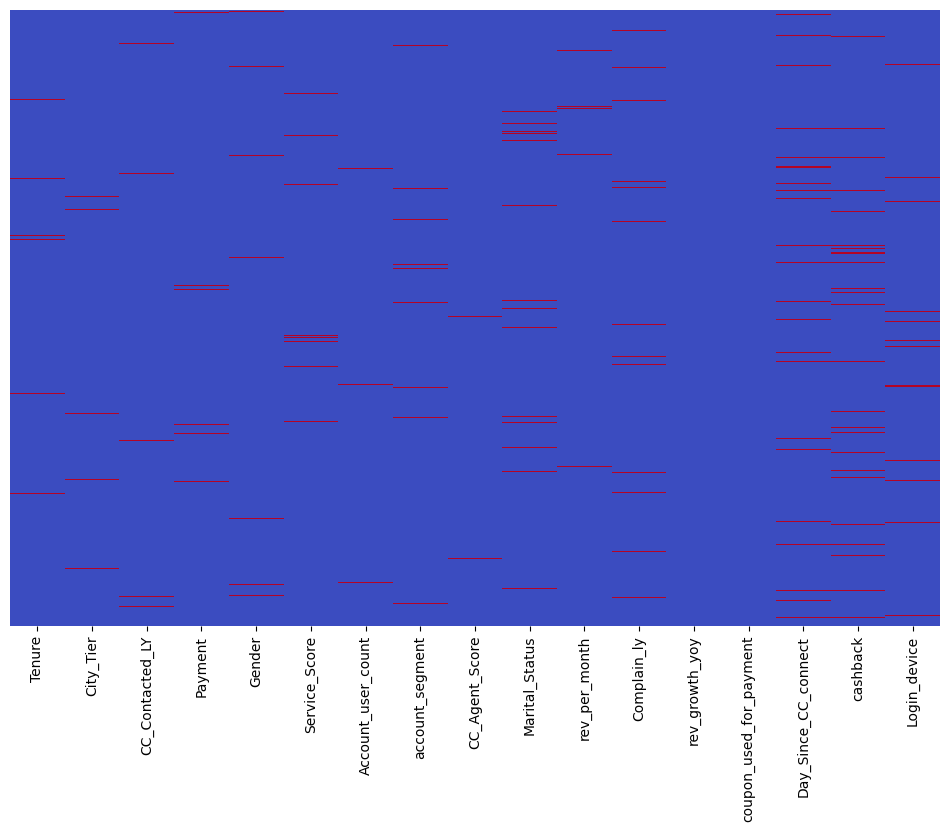

In [ ]:
plt.figure(figsize = (12,8))
sns.heatmap(CC_predictor.isnull(), cbar = False, cmap = 'coolwarm', yticklabels = False)
plt.show()

### Data Cleaning

In [ ]:
## Tenure field

CC.Tenure.value_counts()

,count
Tenure,
1,1351
0,1231
8,519
9,496
7,450
10,423
3,410
4,403
5,403


In [ ]:
##Replacing # in tenure with nulls. There are 116 rows where Tenure has the value '#'. Filling this with np.nan

CC['Tenure'] = CC['Tenure'].replace('#',np.nan)

<ipython-input-17-d38ce7d15720>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['Tenure'] = CC['Tenure'].replace('#',np.nan)


In [ ]:
CC.Tenure.value_counts(dropna=False)

,count
Tenure,
1.0,1351
0.0,1231
8.0,519
9.0,496
7.0,450
10.0,423
3.0,410
4.0,403
5.0,403


In [ ]:
## Checking for City_tier column

CC.City_Tier.value_counts(dropna=False)

,count
City_Tier,
1.0,7263
3.0,3405
2.0,480
NaN,112


In [ ]:
## Checking for CC_Contacted_LY column

CC.CC_Contacted_LY.value_counts(dropna=False)

,count
CC_Contacted_LY,
14.0,682
16.0,663
9.0,655
13.0,655
15.0,623
12.0,571
8.0,538
17.0,525
11.0,524


In [ ]:
## Checking for payment

CC.Payment.value_counts(dropna=False)

,count
Payment,
Debit Card,4587
Credit Card,3511
E wallet,1217
Cash on Delivery,1014
UPI,822
NaN,109


In [ ]:
## Checking for Gender

CC.Gender.value_counts(dropna=False)

,count
Gender,
Male,6328
Female,4178
M,376
F,270
NaN,108


In [ ]:
CC['Gender'] = CC['Gender'].replace('M','Male')

In [ ]:
CC['Gender'] = CC['Gender'].replace('F','Female')

In [ ]:
CC.Gender.value_counts(dropna=False)

,count
Gender,
Male,6704
Female,4448
NaN,108


In [ ]:
## Checking for Service_Score

CC.Service_Score.value_counts(dropna=False)

,count
Service_Score,
3.0,5490
2.0,3251
4.0,2331
NaN,98
1.0,77
0.0,8
5.0,5


In [ ]:
## Checking for Account_user_count

CC.Account_user_count.value_counts(dropna=False)

,count
Account_user_count,
4,4569
3,3261
5,1699
2,526
1,446
@,332
6,315
NaN,112


In [ ]:
CC['Account_user_count'] = CC['Account_user_count'].replace('@',np.nan)

<ipython-input-28-e53145c0dba3>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['Account_user_count'] = CC['Account_user_count'].replace('@',np.nan)


In [ ]:
CC.Account_user_count.value_counts(dropna=False)

,count
Account_user_count,
4.0,4569
3.0,3261
5.0,1699
2.0,526
1.0,446
NaN,444
6.0,315


In [ ]:
## Checking for account_segment

CC.account_segment.value_counts(dropna=False)

,count
account_segment,
Super,4062
Regular Plus,3862
HNI,1639
Super Plus,771
Regular,520
Regular +,262
NaN,97
Super +,47


In [ ]:
CC['account_segment'] = CC['account_segment'].replace( {'Regular +': 'Regular_Plus', 'Super +': 'Super_Plus', 'Super Plus': 'Super_Plus', 'Regular Plus': 'Regular_Plus'} )


In [ ]:
CC.account_segment.value_counts(dropna=False)

,count
account_segment,
Regular_Plus,4124
Super,4062
HNI,1639
Super_Plus,818
Regular,520
NaN,97


In [ ]:
## Checking for CC_Agent_Score

CC.CC_Agent_Score.value_counts(dropna=False)

,count
CC_Agent_Score,
3.0,3360
1.0,2302
5.0,2191
4.0,2127
2.0,1164
NaN,116


In [ ]:
## Checking for Marital_Status

CC.Marital_Status.value_counts(dropna=False)

,count
Marital_Status,
Married,5860
Single,3520
Divorced,1668
NaN,212


In [ ]:
## Checking for rev_per_month

CC.rev_per_month.value_counts(dropna=False)

,count
rev_per_month,
3,1746
2,1585
5,1337
4,1218
6,1085
7,754
+,689
8,643
9,564


In [ ]:
CC['rev_per_month'] = CC['rev_per_month'].replace('+',np.nan)

<ipython-input-36-2e75bcf8e736>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['rev_per_month'] = CC['rev_per_month'].replace('+',np.nan)


In [ ]:
## Checking for Complain_ly

CC.Complain_ly.value_counts(dropna=False)

,count
Complain_ly,
0.0,7792
1.0,3111
NaN,357


In [ ]:
## Checking for rev_growth_yoy

CC.rev_growth_yoy.value_counts(dropna=False)

,count
rev_growth_yoy,
14,1524
13,1427
15,1283
12,1210
16,949
18,708
17,704
19,619
20,562


In [ ]:
CC['rev_growth_yoy'] = CC['rev_growth_yoy'].replace('$',np.nan)

<ipython-input-39-eb14f698bf41>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['rev_growth_yoy'] = CC['rev_growth_yoy'].replace('$',np.nan)


In [ ]:
CC.rev_growth_yoy.value_counts(dropna=False)

,count
rev_growth_yoy,
14.0,1524
13.0,1427
15.0,1283
12.0,1210
16.0,949
18.0,708
17.0,704
19.0,619
20.0,562


In [ ]:
## Checking for coupon_used_for_payment

CC.coupon_used_for_payment.value_counts(dropna=False)

,count
coupon_used_for_payment,
1,4373
2,2656
0,2150
3,698
4,424
5,284
6,234
7,184
8,88


In [ ]:
CC['coupon_used_for_payment'] = CC['coupon_used_for_payment'].replace( {'#': np.nan, '*': np.nan, '$': np.nan} )

<ipython-input-42-b5c2985ce588>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['coupon_used_for_payment'] = CC['coupon_used_for_payment'].replace( {'#': np.nan, '*': np.nan, '$': np.nan} )


In [ ]:
CC.coupon_used_for_payment.value_counts(dropna=False)

,count
coupon_used_for_payment,
1.0,4373
2.0,2656
0.0,2150
3.0,698
4.0,424
5.0,284
6.0,234
7.0,184
8.0,88


In [ ]:
## Checking for Day_Since_CC_connect

CC.Day_Since_CC_connect.value_counts(dropna=False)

,count
Day_Since_CC_connect,
3,1816
2,1574
1,1256
8,1169
0,964
7,911
4,893
9,622
5,479


In [ ]:
CC['Day_Since_CC_connect'] = CC['Day_Since_CC_connect'].replace('$',np.nan)

<ipython-input-45-26f1cb3c0abf>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['Day_Since_CC_connect'] = CC['Day_Since_CC_connect'].replace('$',np.nan)


In [ ]:
CC.Day_Since_CC_connect.value_counts(dropna=False)

,count
Day_Since_CC_connect,
3.0,1816
2.0,1574
1.0,1256
8.0,1169
0.0,964
7.0,911
4.0,893
9.0,622
5.0,479


In [ ]:
## Checking for cashback

CC.cashback.value_counts(dropna=False)

,count
cashback,
NaN,471
155.62,10
149.68,9
149.36,9
154.73,9
...,...
235.22,1
262.06,1
177.98,1


In [ ]:
CC[CC['cashback'] == '$']

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
440,20440,0,0.0,1.0,16.0,Credit Card,Male,3.0,2.0,Regular_Plus,3.0,Single,2.0,0.0,18.0,1.0,2.0,$,Mobile
1257,21257,0,4.0,1.0,9.0,Credit Card,Male,2.0,3.0,Regular_Plus,5.0,Married,NaN,NaN,13.0,0.0,3.0,$,Computer


In [ ]:
CC['cashback'] = CC['cashback'].replace('$',np.nan)

<ipython-input-49-3fd185bc7693>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['cashback'] = CC['cashback'].replace('$',np.nan)


In [ ]:
CC.cashback.dtype

dtype('float64')

In [ ]:
## Checking for Login_device

CC.Login_device.value_counts(dropna=False)

,count
Login_device,
Mobile,7482
Computer,3018
&&&&,539
NaN,221


In [ ]:
CC['Login_device'] = CC['Login_device'].replace('&&&&',np.nan)

In [ ]:
CC.Login_device.value_counts(dropna=False)

,count
Login_device,
Mobile,7482
Computer,3018
NaN,760


After Data Cleaning

In [ ]:

CC.drop("AccountID", axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,11260.0,0.168384,0.374223,0.0,0.00,0.00,0.00,1.0
Tenure,11042.0,11.025086,12.879782,0.0,2.00,9.00,16.00,99.0
City_Tier,11148.0,1.653929,0.915015,1.0,1.00,1.00,3.00,3.0
CC_Contacted_LY,11158.0,17.867091,8.853269,4.0,11.00,16.00,23.00,132.0
Service_Score,11162.0,2.902526,0.725584,0.0,2.00,3.00,3.00,5.0
Account_user_count,10816.0,3.692862,1.022976,1.0,3.00,4.00,4.00,6.0
CC_Agent_Score,11144.0,3.066493,1.379772,1.0,2.00,3.00,4.00,5.0
rev_per_month,10469.0,6.362594,11.909686,1.0,3.00,5.00,7.00,140.0
Complain_ly,10903.0,0.285334,0.451594,0.0,0.00,0.00,1.00,1.0
rev_growth_yoy,11257.0,16.193391,3.757721,4.0,13.00,15.00,19.00,28.0


### After data cleaning null check

In [ ]:
CC_predictor = CC.drop(['AccountID','Churn'],axis=1)

print("\nTotal number of nulls in all predictor fields ")
print(CC_predictor.isnull().sum().sum())

print("\nTotal % nulls in all predictor fields ")
print(round(((CC_predictor.isnull().sum().sum()/ CC_predictor.size) * 100 ),2))

## Percentage nulls by column in predictor dataset
print("\n\nProportion of nulls by column - multiply by 100 for percentage")
print(CC_predictor.isnull().sum().sort_values(ascending = False)/CC_predictor.index.size)

## Rows that have more than 4 null fields
print("\n\nRows that have more than 4 null fields")
CC_predictor_temp = CC_predictor[CC_predictor.isnull().sum(axis = 1) >= 4]
CC_predictor_temp


Total number of nulls in all predictor fields 
4361

Total % nulls in all predictor fields 
2.28


Proportion of nulls by column - multiply by 100 for percentage
rev_per_month              0.070249
Login_device               0.067496
cashback                   0.042007
Account_user_count         0.039432
Day_Since_CC_connect       0.031794
Complain_ly                0.031705
Tenure                     0.019361
Marital_Status             0.018828
CC_Agent_Score             0.010302
City_Tier                  0.009947
Payment                    0.009680
Gender                     0.009591
CC_Contacted_LY            0.009059
Service_Score              0.008703
account_segment            0.008615
rev_growth_yoy             0.000266
coupon_used_for_payment    0.000266
dtype: float64


Rows that have more than 4 null fields


,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device


### Outlier checking

In [ ]:
## Making a separate list for numeric and categorical columns

num_cols = ['Tenure', 'CC_Contacted_LY', 'rev_per_month','rev_growth_yoy','coupon_used_for_payment','Day_Since_CC_connect','cashback']
cat_cols = ['City_Tier','Payment','Gender','Service_Score','Account_user_count','account_segment','CC_Agent_Score','Marital_Status','Complain_ly','Login_device']

In [ ]:
## Get upper bound and lower bound
Q1 = CC_predictor[num_cols].quantile(0.25)
Q3 = CC_predictor[num_cols].quantile(0.75)
IQR = Q3 - Q1
UL = Q3 + 1.5*IQR
LL = Q1 - 1.5*IQR

In [ ]:
print ("Proportion of outliers in numeric continuous columns \n")
(((CC_predictor[num_cols] > UL) | (CC_predictor[num_cols] < LL)).sum())/ CC_predictor.shape[0]

Proportion of outliers in numeric continuous columns 



,0
Tenure,0.012345
CC_Contacted_LY,0.003730
rev_per_month,0.016430
rev_growth_yoy,0.000000
coupon_used_for_payment,0.122558
Day_Since_CC_connect,0.002931
cashback,0.078064


In [ ]:
print ("Number of outliers in numeric continuous columns \n")
((CC_predictor[num_cols] > UL) | (CC_predictor[num_cols] < LL)).sum().sum()

Number of outliers in numeric continuous columns 



np.int64(2658)

In [ ]:
print ("Proportion of outliers in all numeric continuous columns \n")
((CC_predictor[num_cols] > UL) | (CC_predictor[num_cols] < LL)).sum().sum()/(CC_predictor.shape[0]*CC_predictor.shape[1])

Proportion of outliers in all numeric continuous columns 



np.float64(0.013885696374464528)

In [ ]:
CC_predictor.shape

(11260, 17)

## Univariate Analysis

### Univariate Analysis for continuous data

#### Box plot for continuous variables

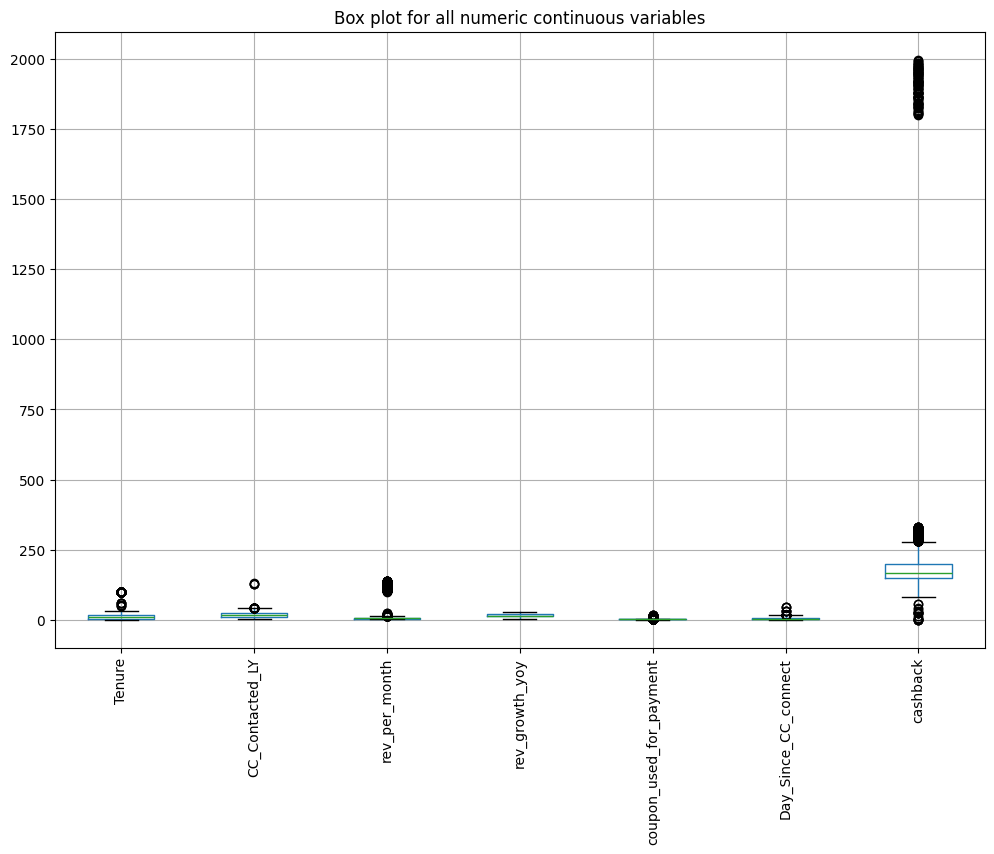

In [ ]:
plt.figure(figsize=(12,8))
CC_predictor[num_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Box plot for all numeric continuous variables");

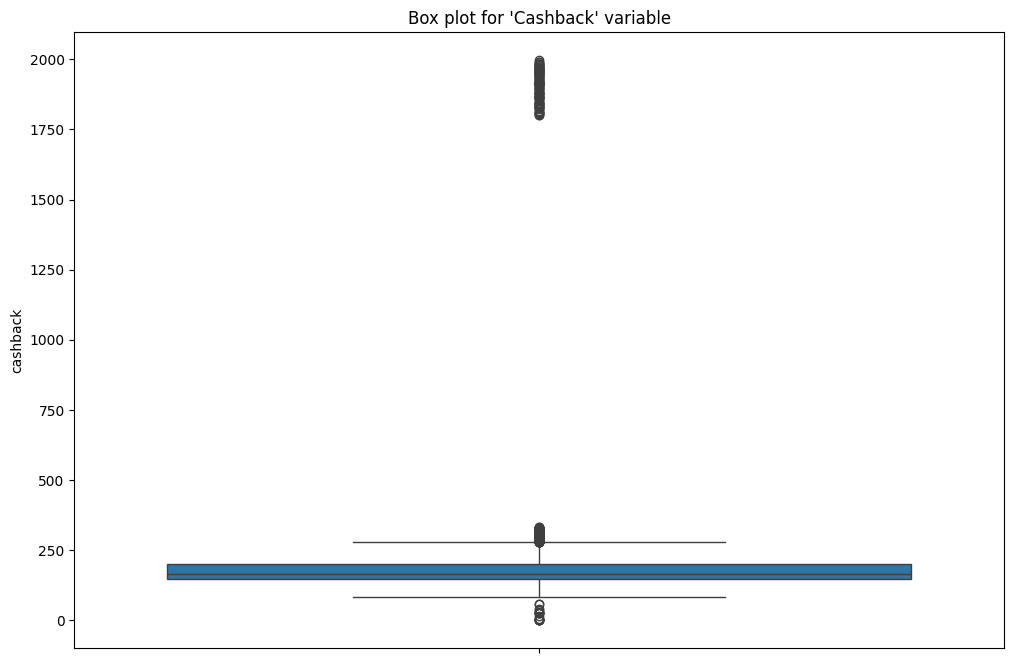

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(data=CC, y='cashback')
plt.xticks(rotation=90)
plt.title("Box plot for 'Cashback' variable");

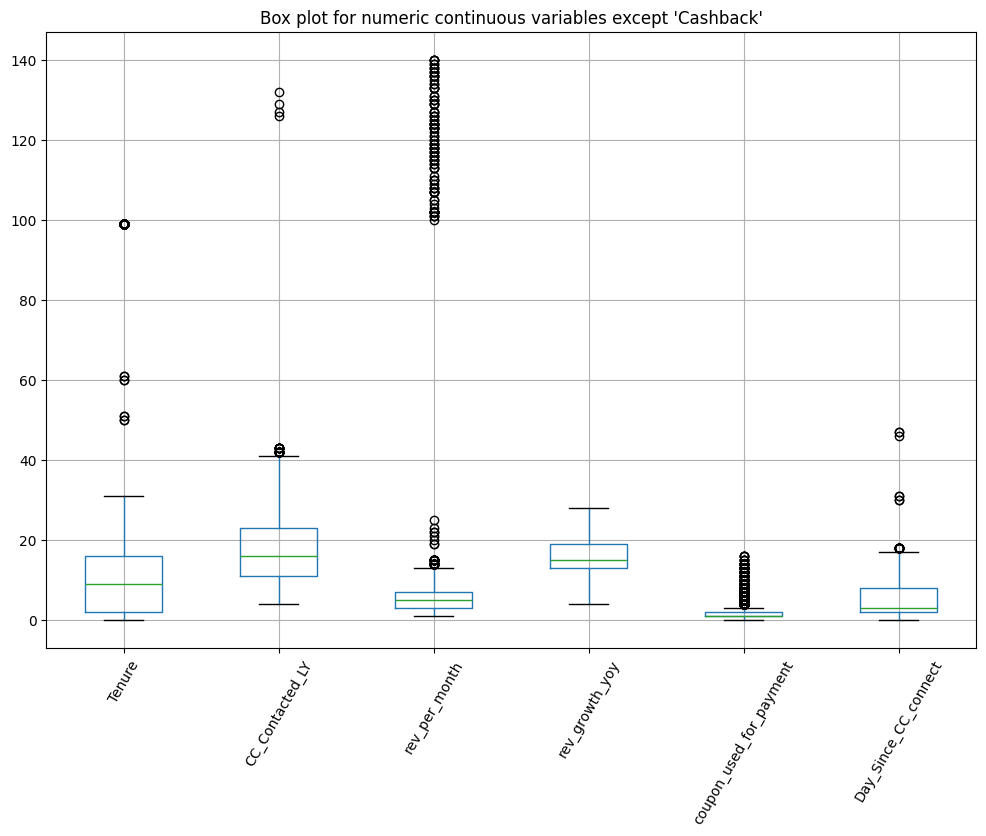

In [ ]:
plt.figure(figsize=(12,8))
CC_predictor[num_cols].drop('cashback',axis=1).boxplot()
plt.xticks(rotation=60)
plt.title("Box plot for numeric continuous variables except 'Cashback'");

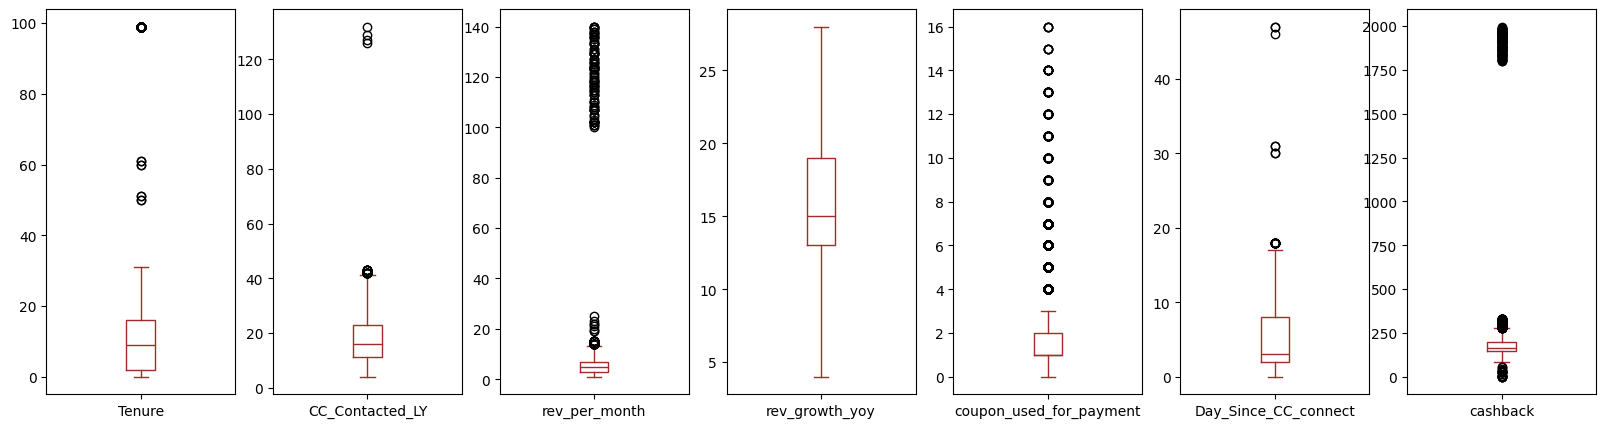

In [ ]:
CC[num_cols].plot(kind = 'box', subplots = True,
       figsize = (20,5), color = 'brown');
#plt.title("Boxplot for numeric columns");

In [ ]:
CC['coupon_used_for_payment'].value_counts()

,count
coupon_used_for_payment,
1.0,4373
2.0,2656
0.0,2150
3.0,698
4.0,424
5.0,284
6.0,234
7.0,184
8.0,88


In [ ]:
Outlier_treat_vars = ['Tenure','CC_Contacted_LY','rev_per_month','Day_Since_CC_connect', 'cashback']

#### Histogram for continuous variables

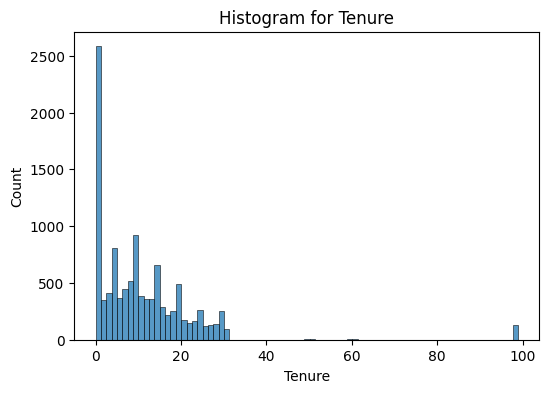

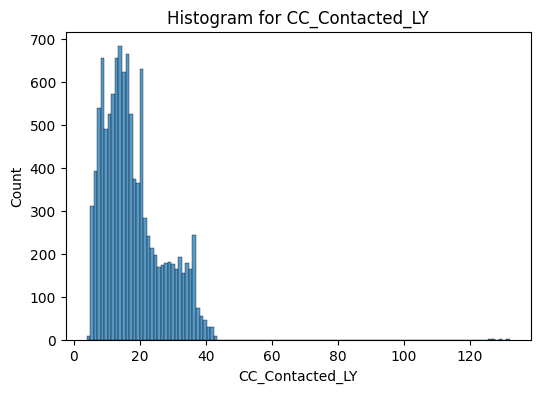

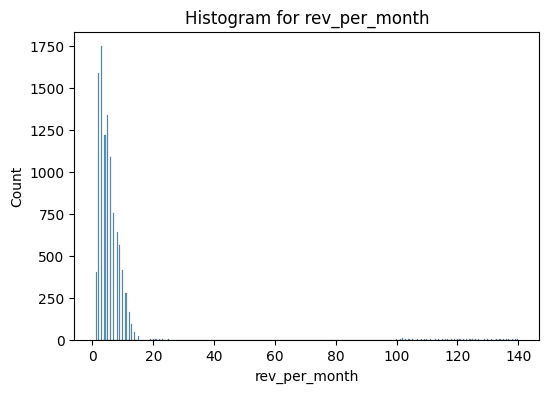

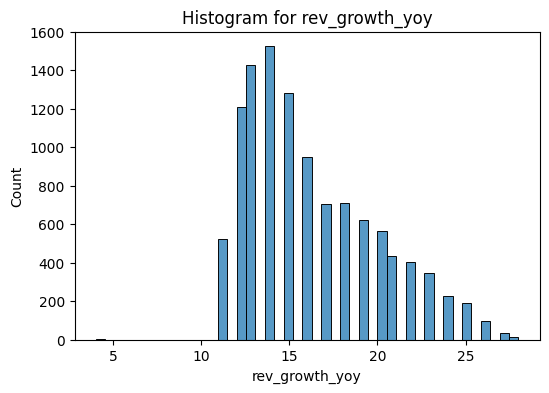

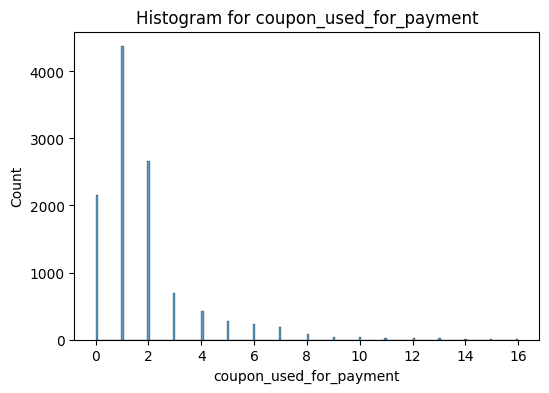

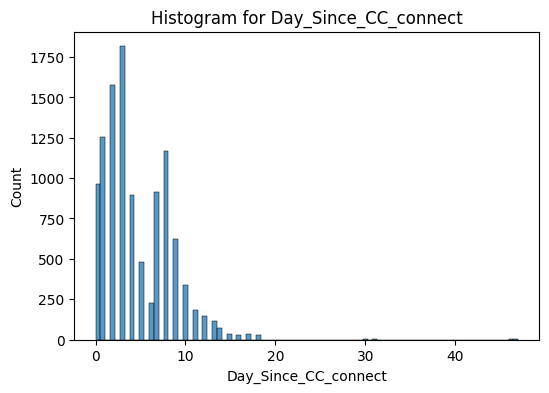

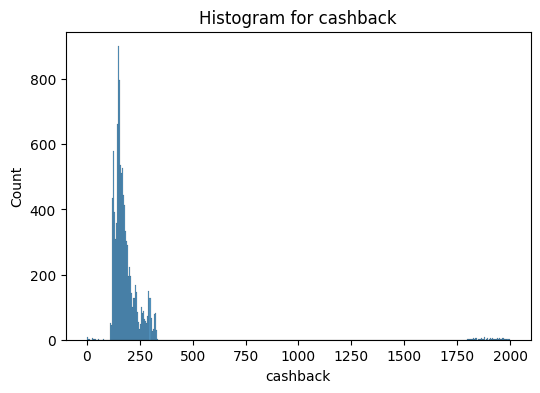

In [ ]:
## Using histplot
for i in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=CC, x=i)
    plot_title = 'Histogram for ' + i
    plt.title(plot_title)
    plt.show();

In [ ]:
cols = ['Skewness']
pd.DataFrame(CC[num_cols].skew(skipna=True).round(2), columns=cols)

,Skewness
Tenure,3.90
CC_Contacted_LY,1.42
rev_per_month,9.09
rev_growth_yoy,0.75
coupon_used_for_payment,2.58
Day_Since_CC_connect,1.27
cashback,8.77


Count plot for categorical variables

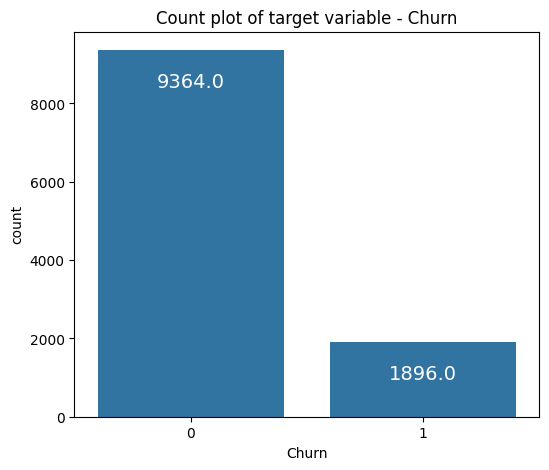

In [ ]:
## Count plot of target column


plt.figure(figsize=(6,5))
ax = sns.countplot(x='Churn', data=CC)

for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.4, p.get_height()), ha='center', va='top', color='white', size=14)
plt.title("Count plot of target variable - Churn");


In [ ]:
## Checking for balance of target variable in the dataset

(CC['Churn'].value_counts(normalize=True).round(3)) * 100

,proportion
Churn,
0,83.2
1,16.8


#### Other categorical variables

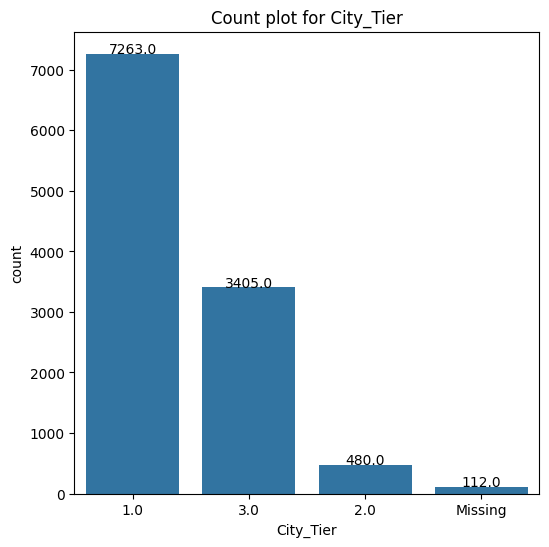

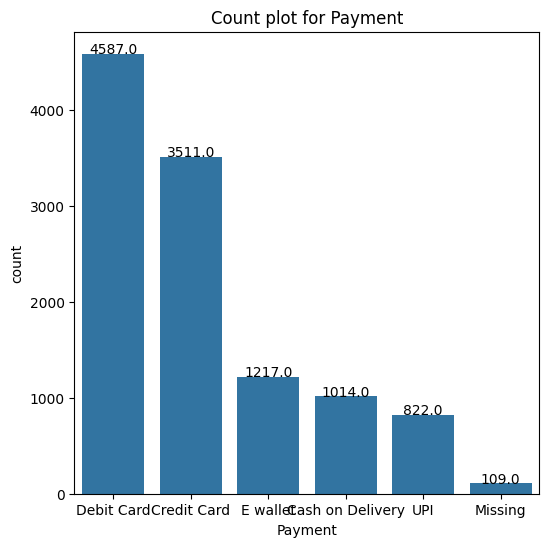

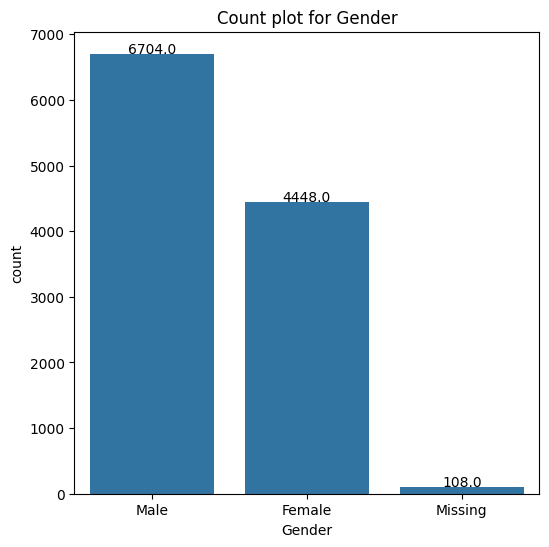

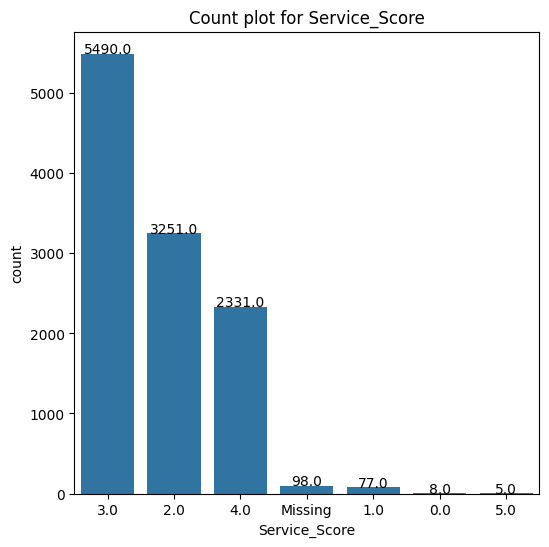

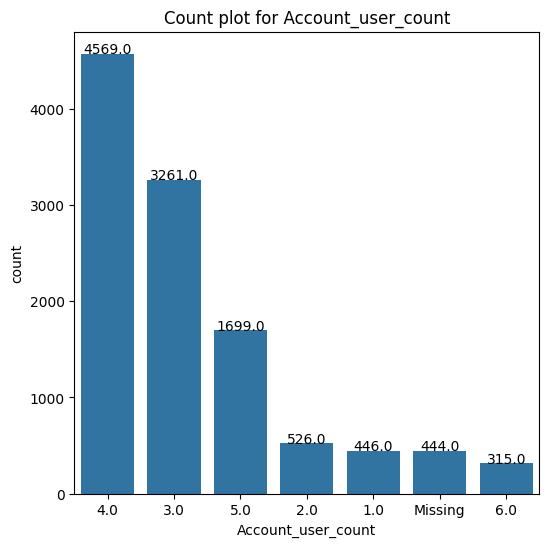

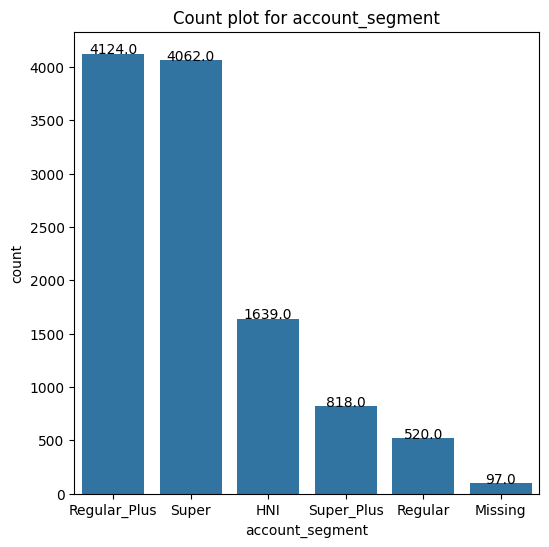

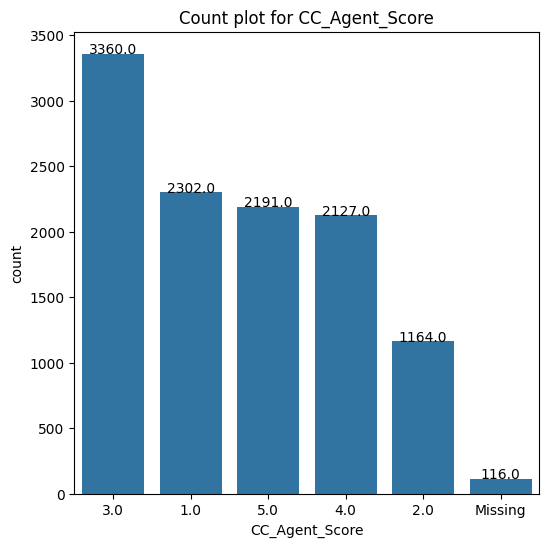

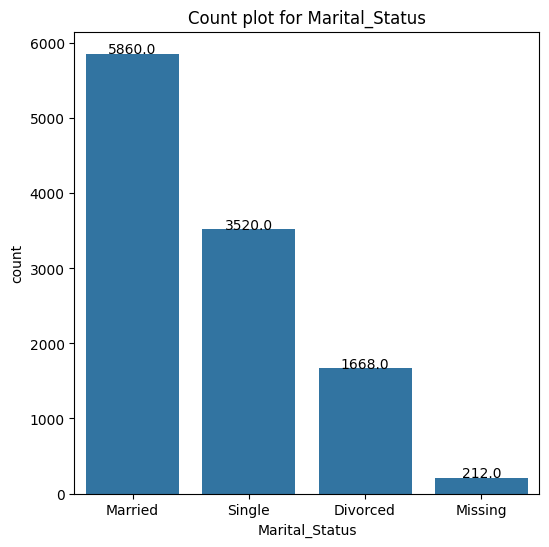

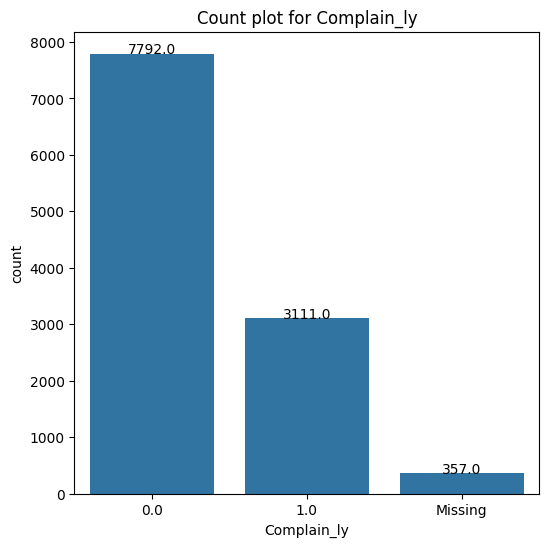

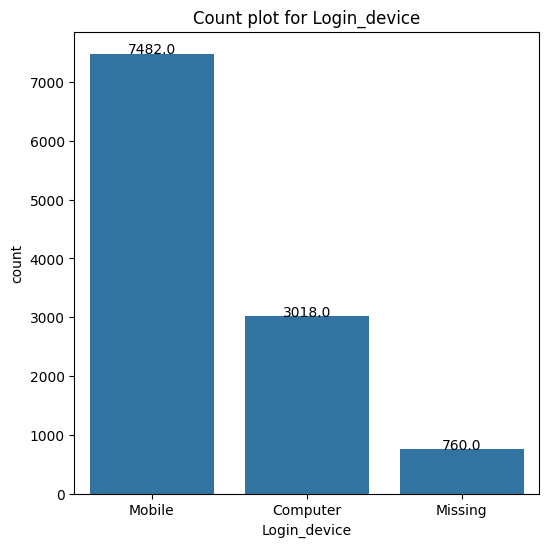

In [ ]:
df = pd.DataFrame()
for i in cat_cols:
    plt.figure(figsize=(6,6))

    df[i] = CC[i].fillna("Missing")
    order = df[i].value_counts(ascending=False).index
    ax = sns.countplot(x=df[i],order=order)

    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2., height+1, height, ha="center")

    plot_title = 'Count plot for ' + i
    plt.title(plot_title)
    plt.show();

### Bivariate analysis - Numerical fields vs Churn
#### Histogram and boxplots with hue

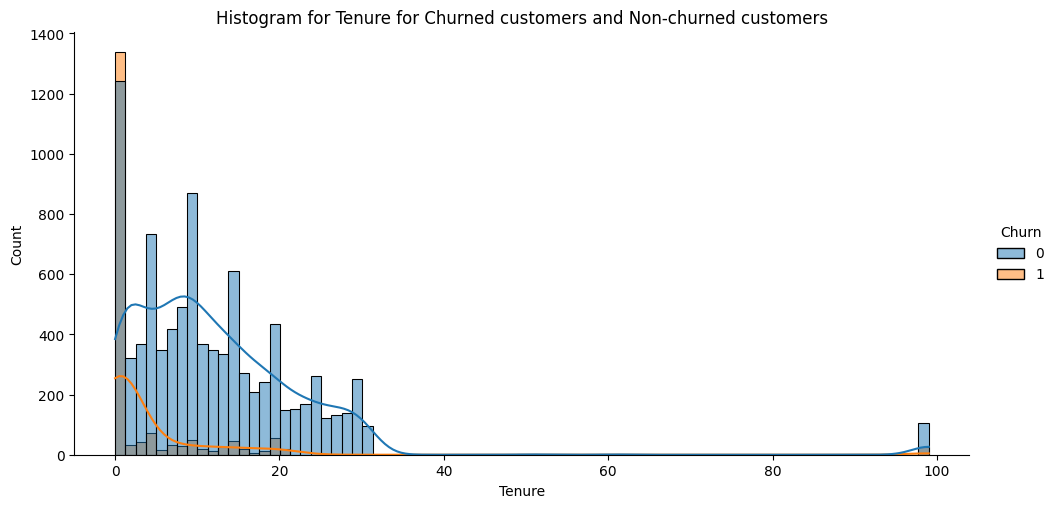

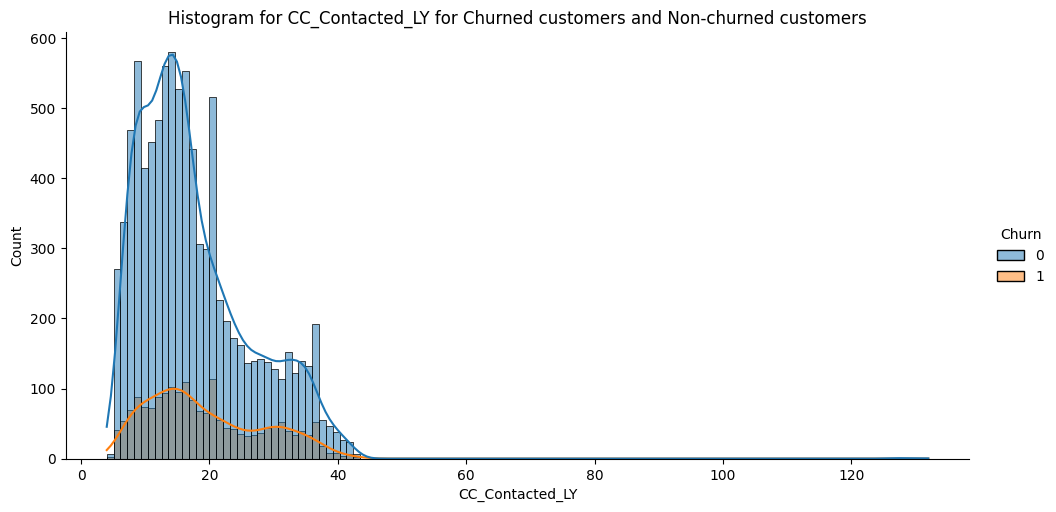

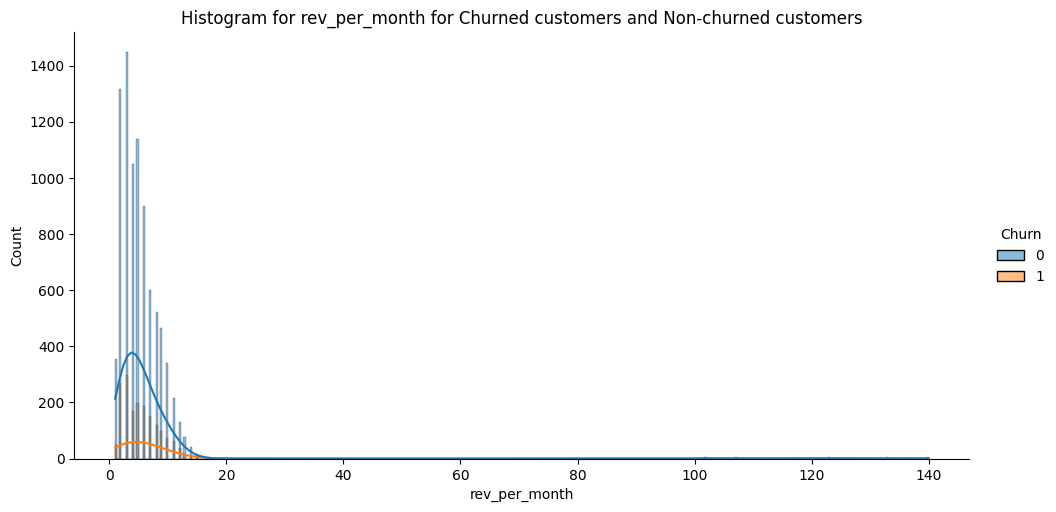

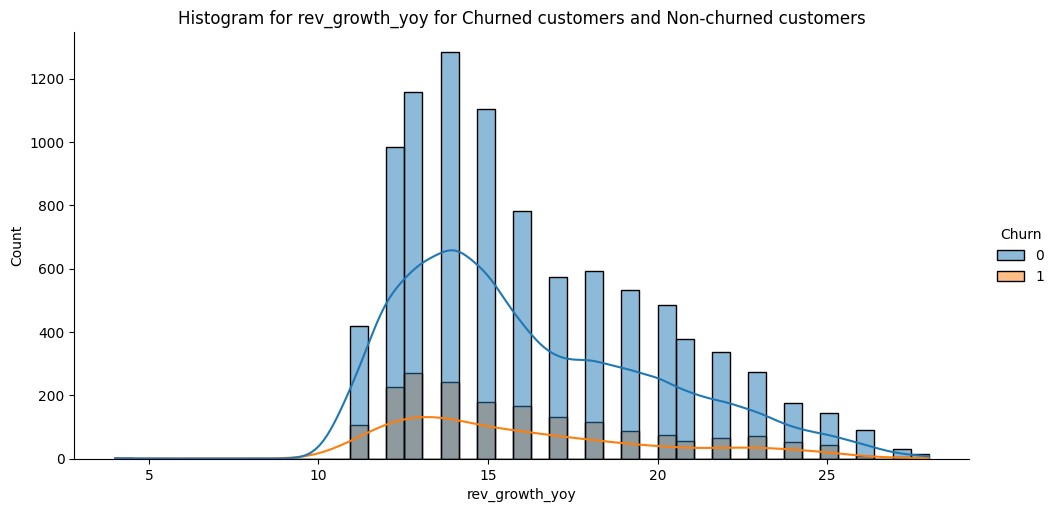

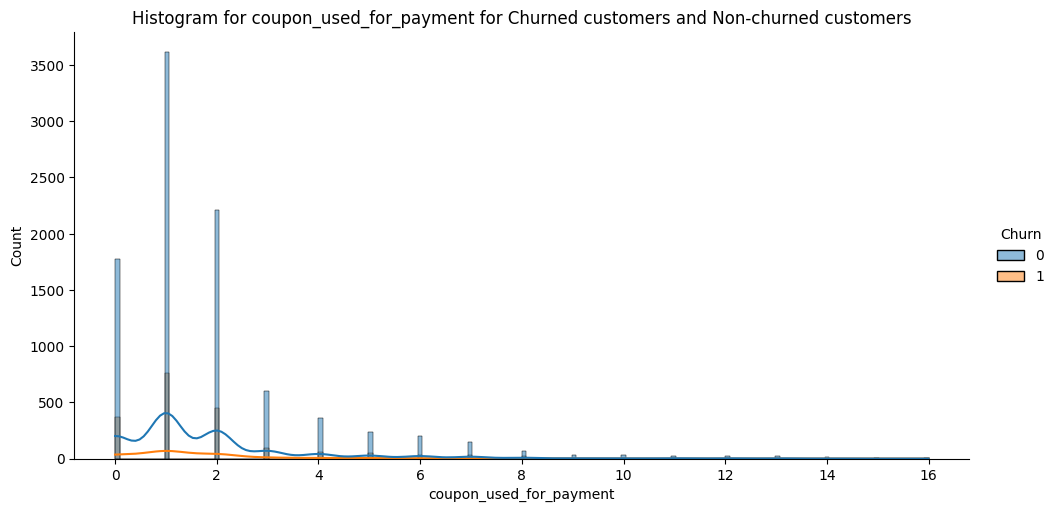

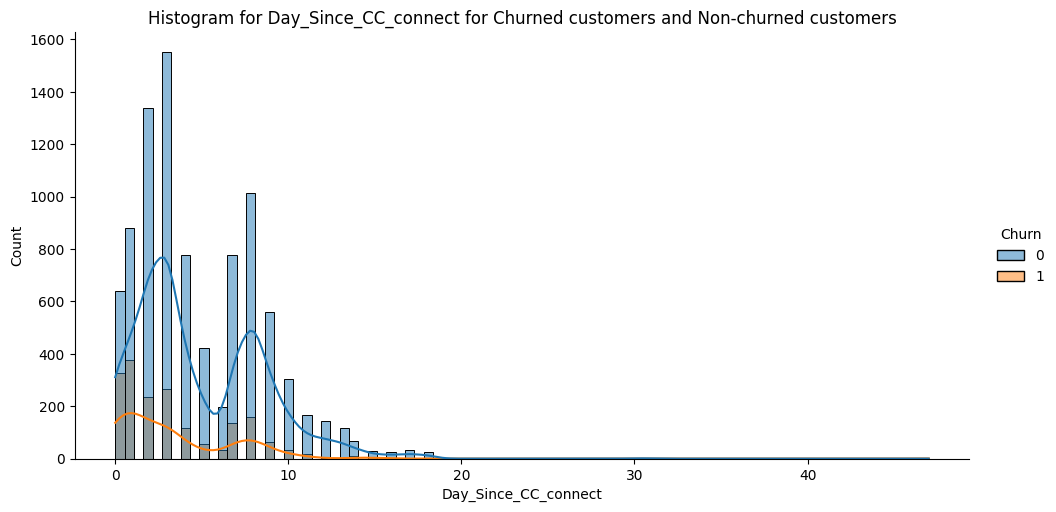

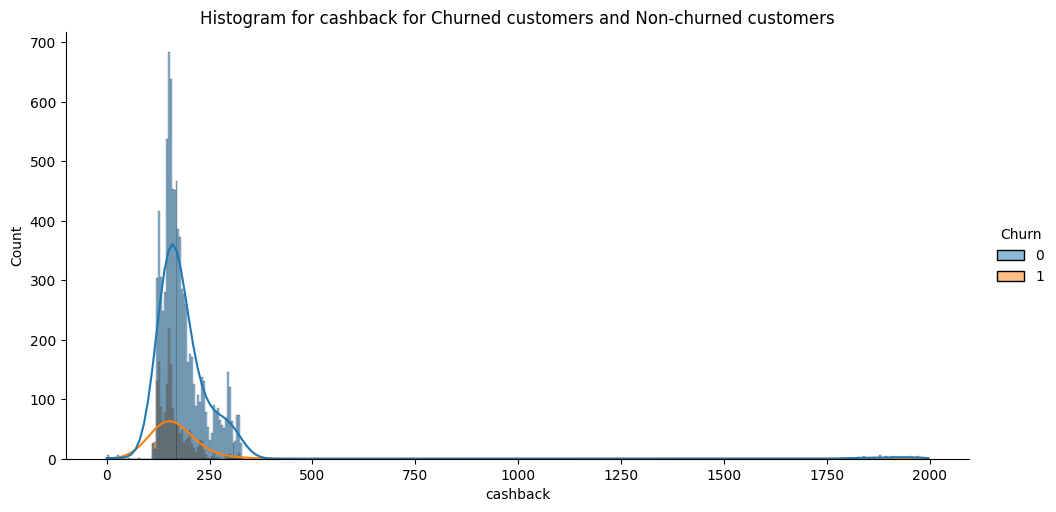

In [ ]:
for i in num_cols:
    sns.displot(x=CC[i], hue=CC['Churn'], kind='hist', kde=True, aspect=2)
    plot_title = "Histogram for " + i + " for Churned customers and Non-churned customers"
    plt.title(plot_title)
    plt.show();

In [ ]:
##Box plot errors if 0 and 1s are left as-is or datatype converted as object/categorical. Hence converting to string
##Need to convert back after analysis
CC['Churn'] = CC['Churn'].replace( {1: 'Churned', 0: 'Current'} )

In [ ]:
CC.Churn.value_counts(normalize=True)

,proportion
Churn,
Current,0.831616
Churned,0.168384


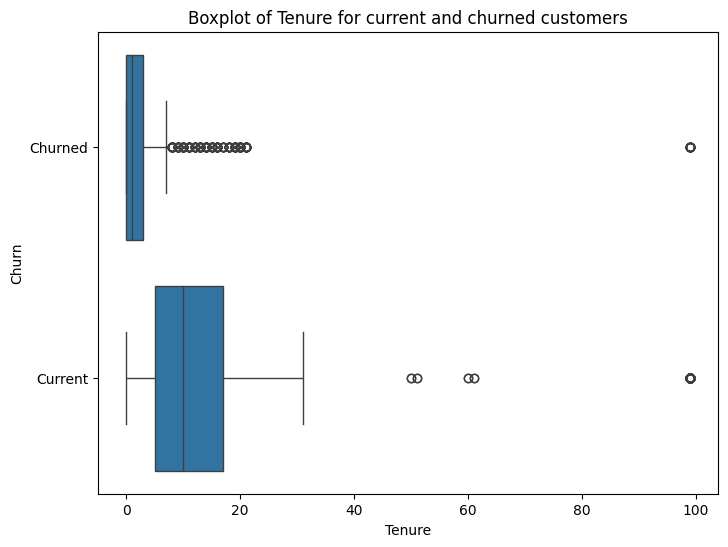

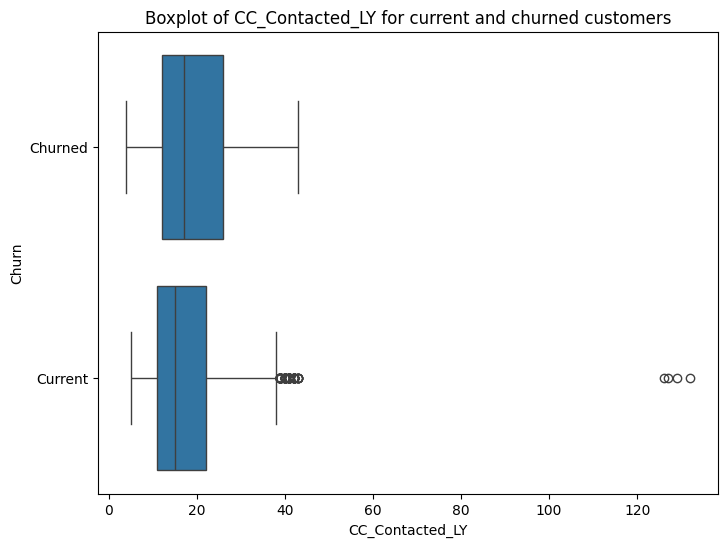

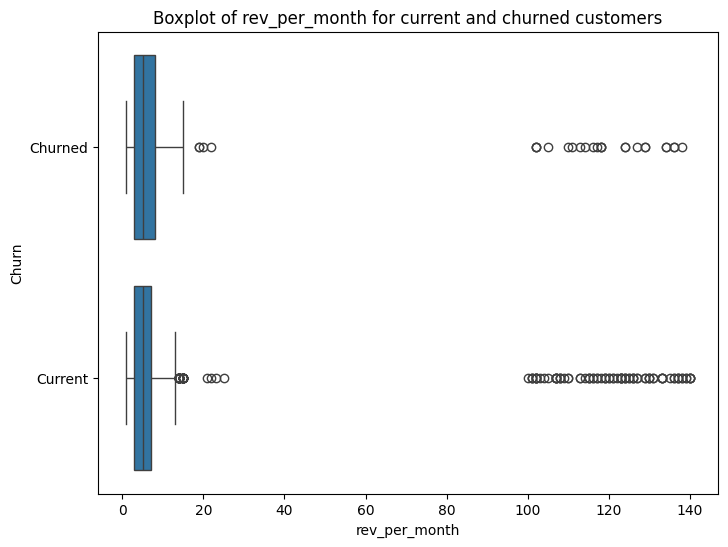

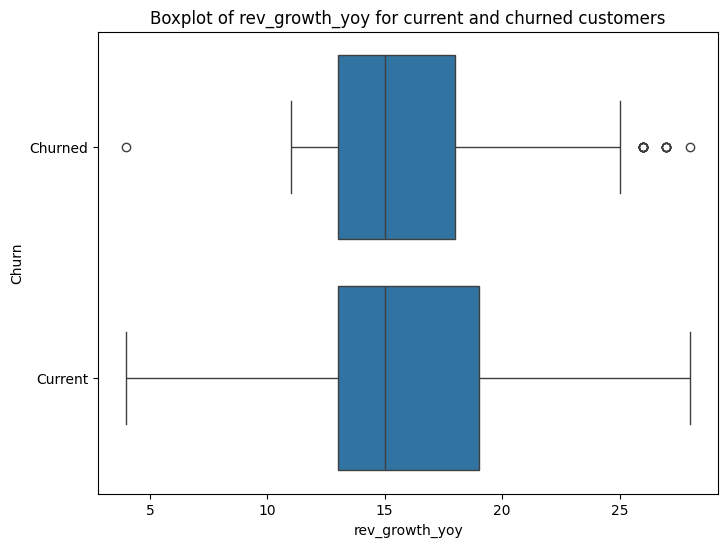

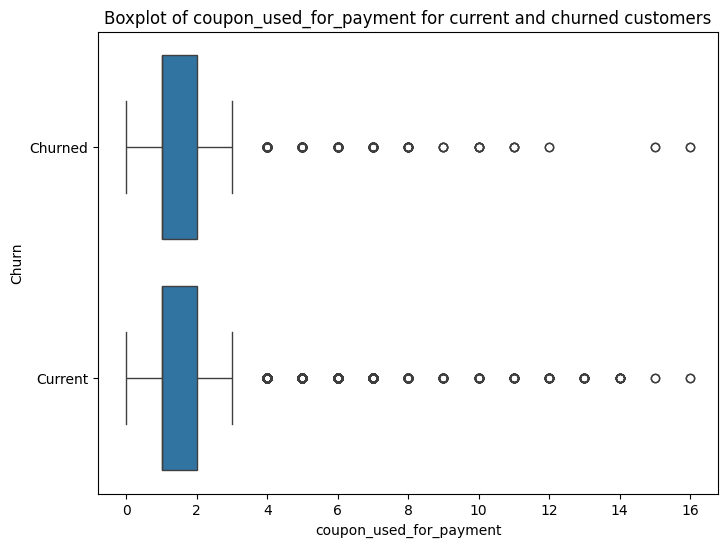

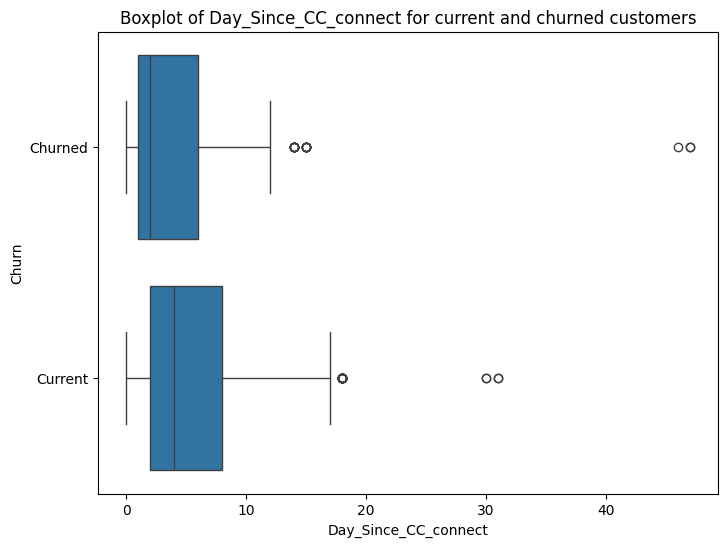

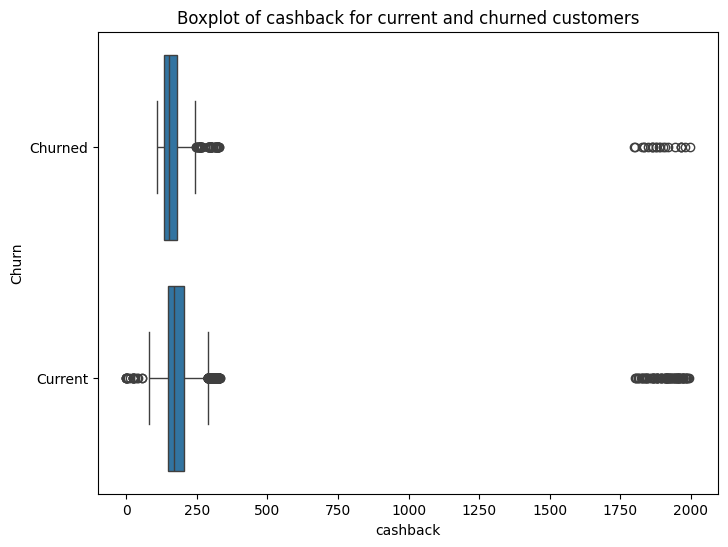

In [ ]:
for i in num_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=CC[i], y=CC['Churn'])
    plot_title = 'Boxplot of ' + i + " for current and churned customers"
    plt.title(plot_title)
    plt.show();

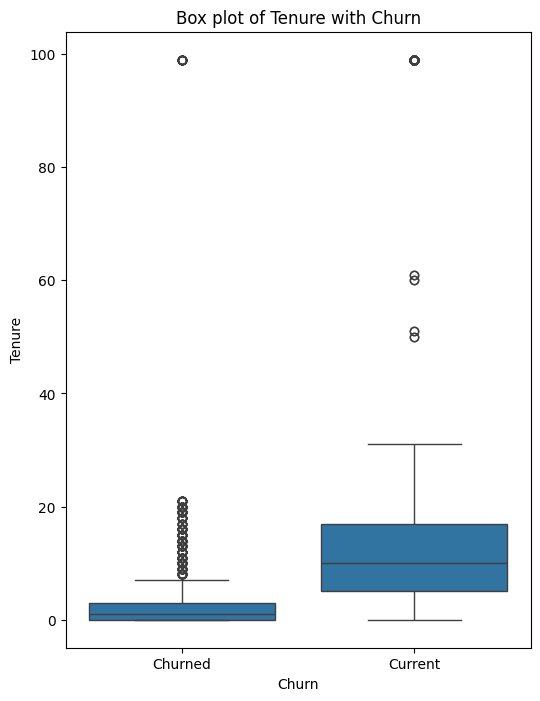

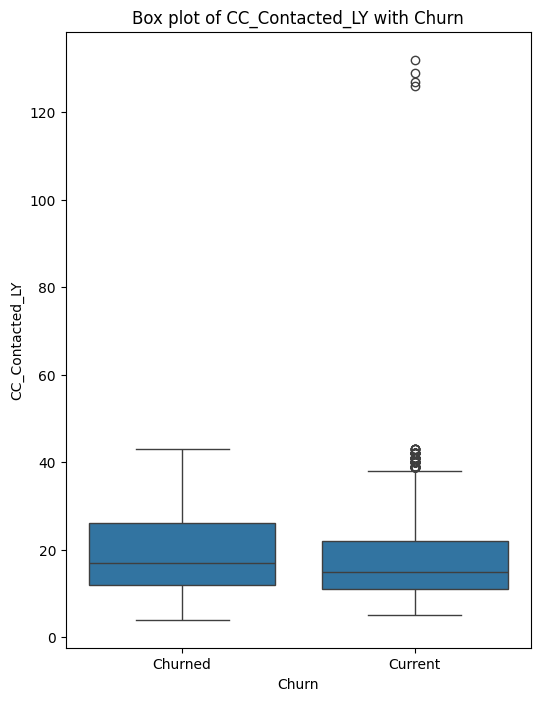

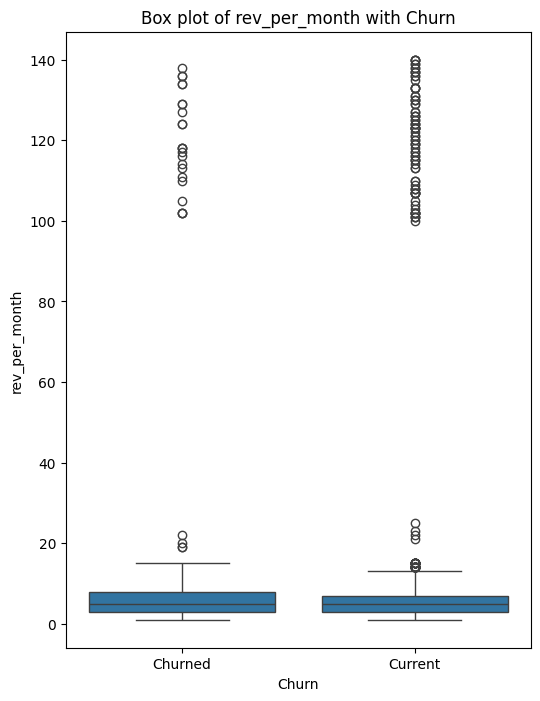

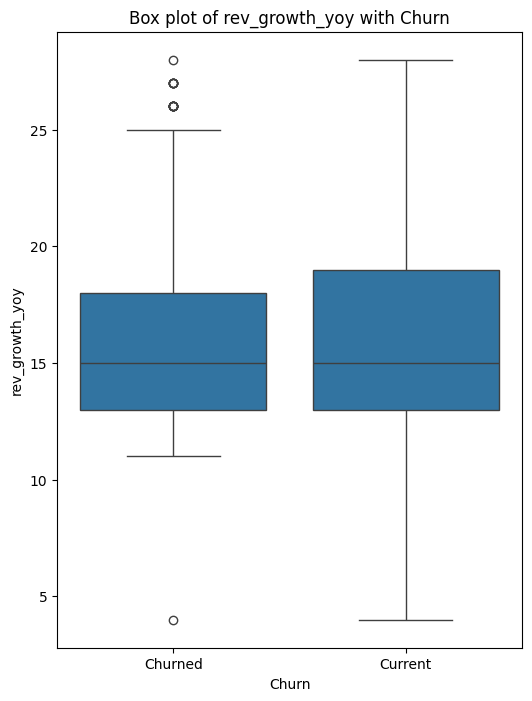

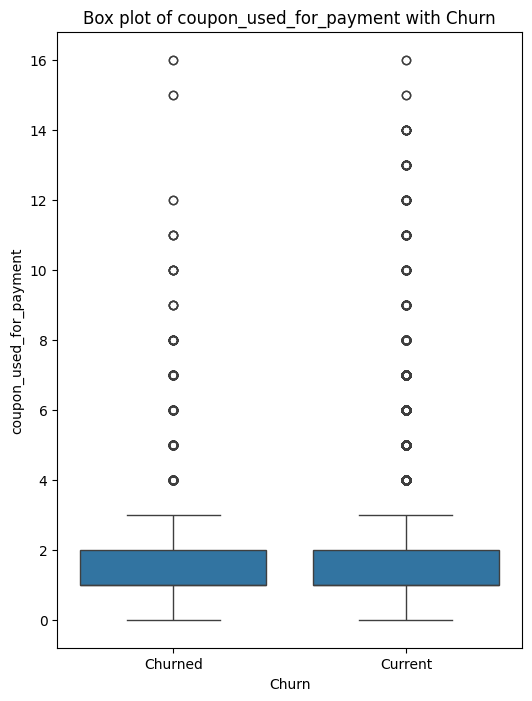

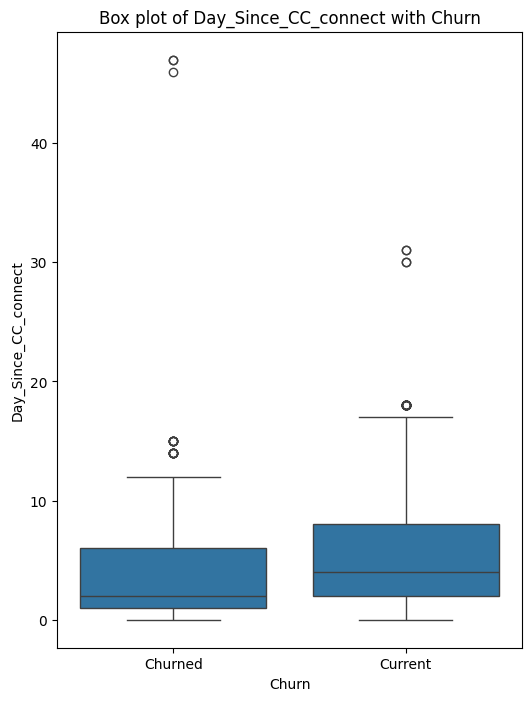

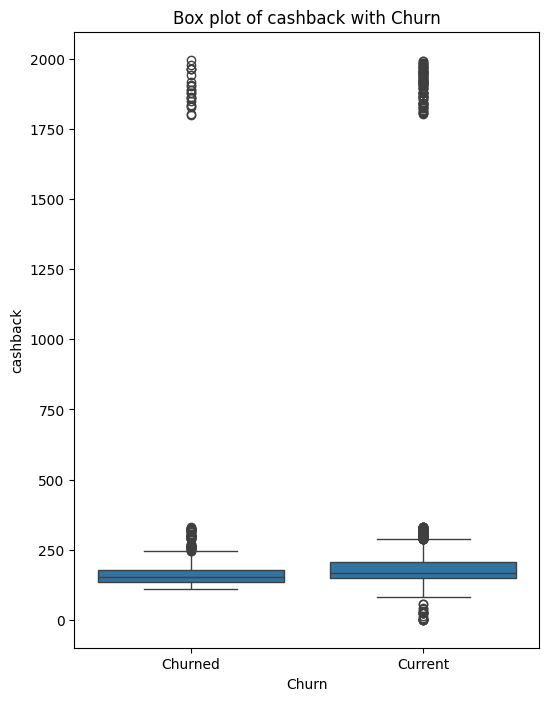

In [ ]:
for i in num_cols:
    plt.figure(figsize=(6,8))
    sns.boxplot(data = CC, y=i, x='Churn')
    plot_title = "Box plot of "+i+" with Churn"
    plt.title(plot_title)
    plt.show();

### Bivariate Analysis - Categorical vs Churn
#### Count plots and stacked bar

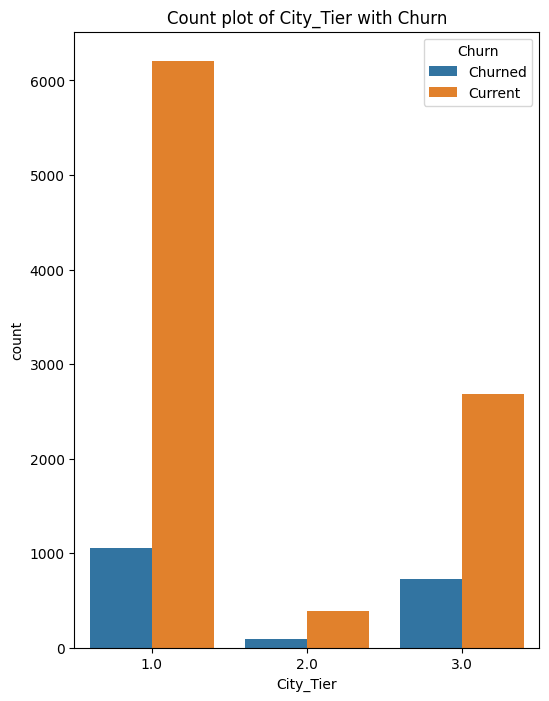

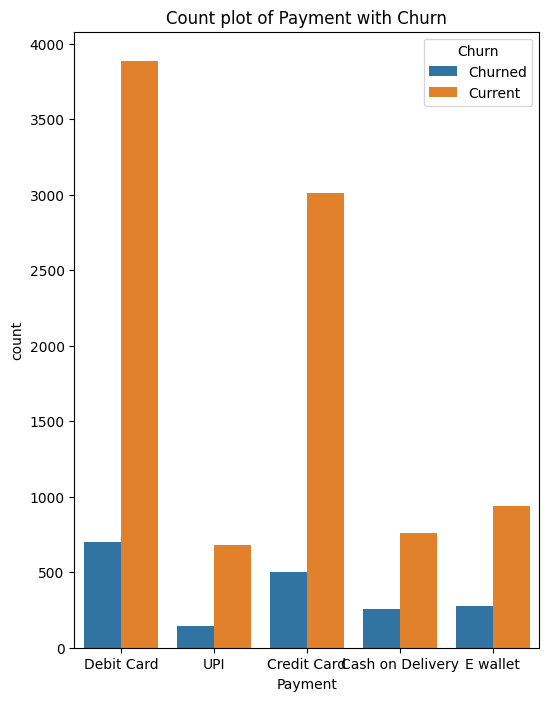

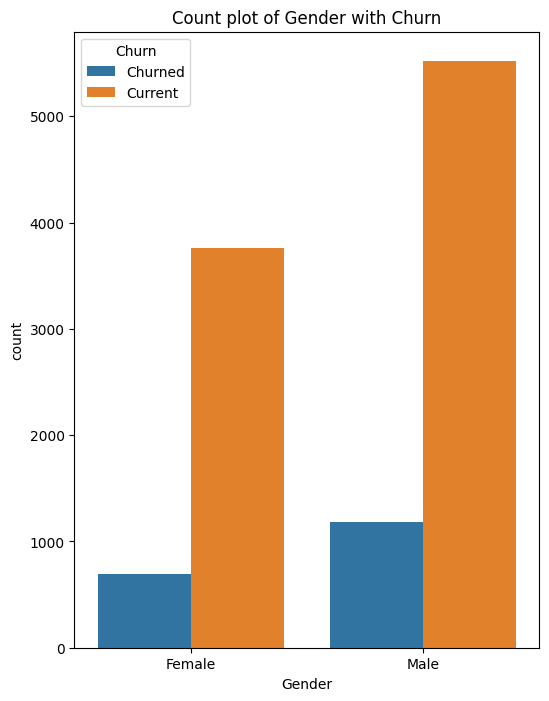

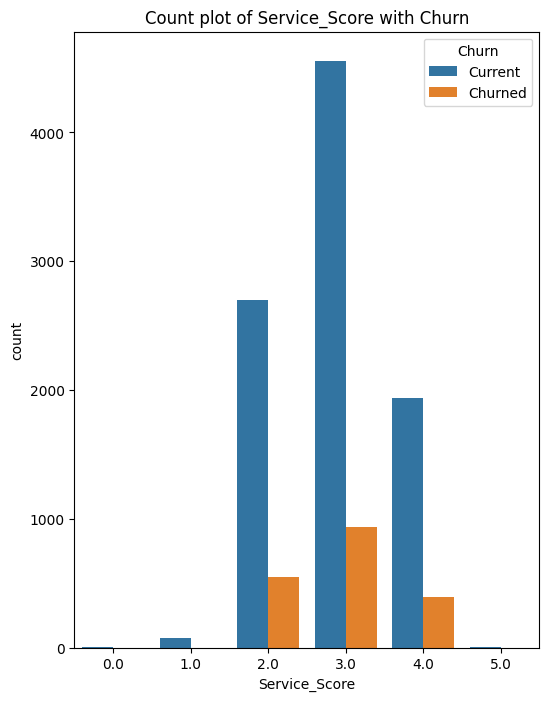

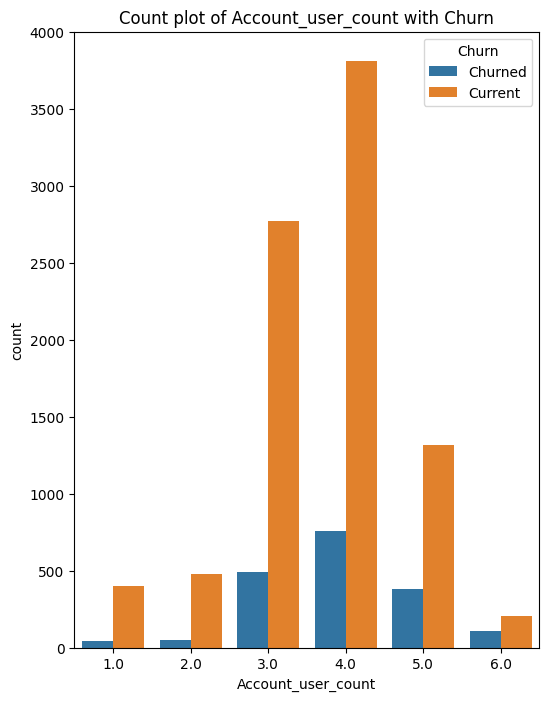

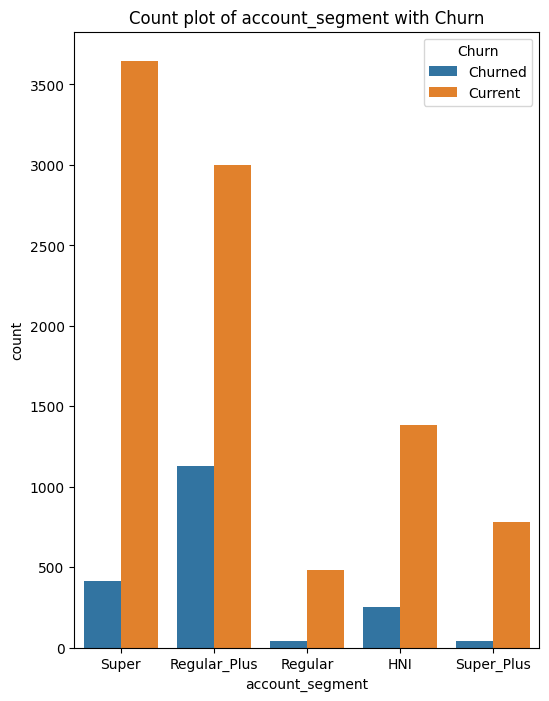

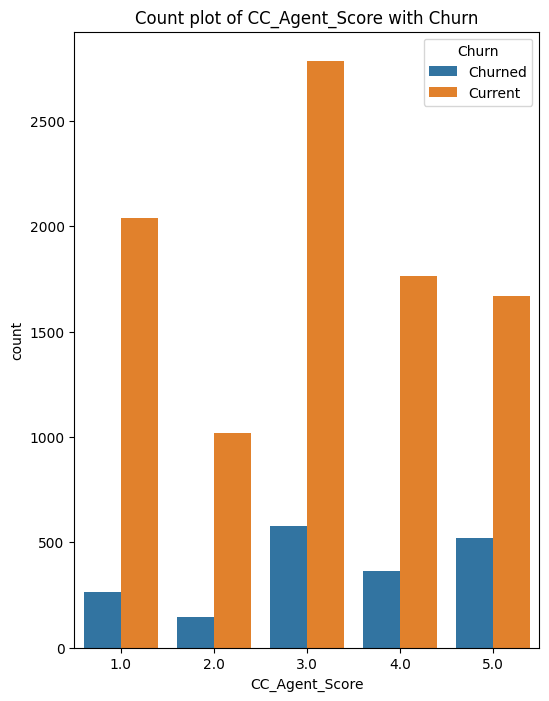

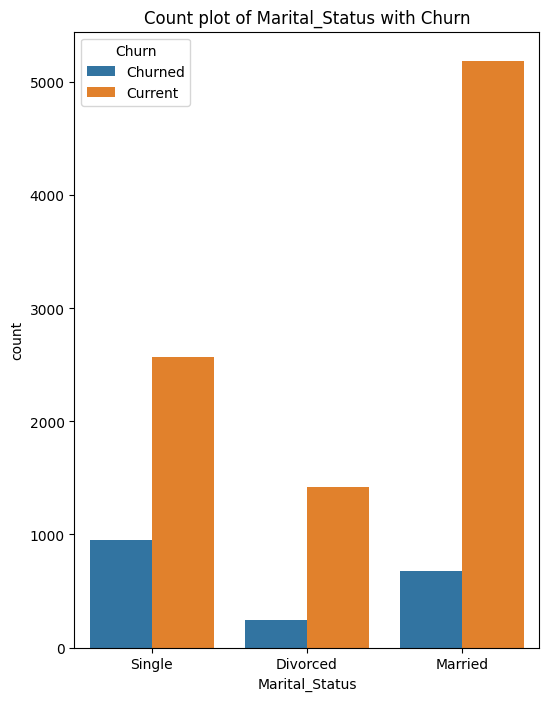

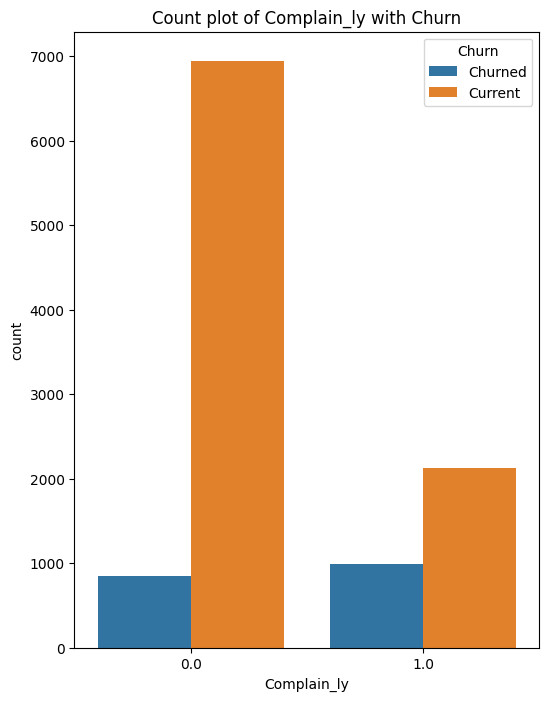

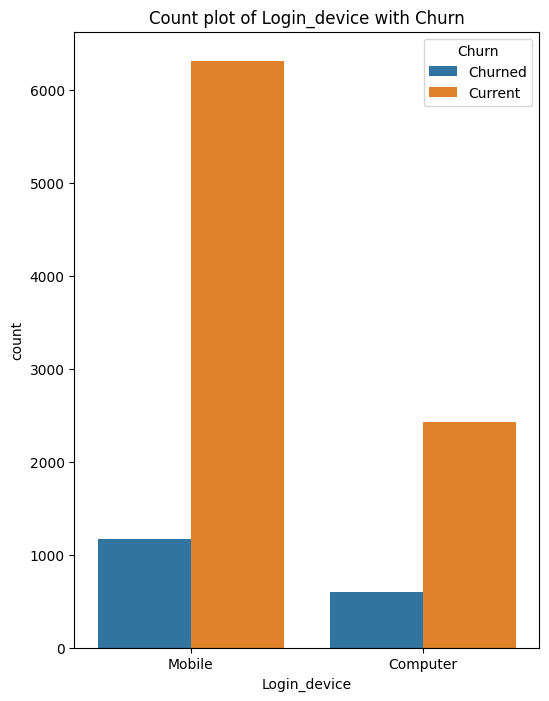

In [ ]:
## Countplot with hue

for i in cat_cols:
    plt.figure(figsize=(6,8))
    sns.countplot(data = CC, x=i, hue='Churn')
    plot_title = "Count plot of "+i+" with Churn"
    plt.title(plot_title)
    plt.show();

In [ ]:
pd.pivot_table(CC, values='AccountID', index=['Churn'], columns=['Login_device'], aggfunc='count', margins=True)

Login_device,Computer,Mobile,All
Churn,,,
Churned,597,1172,1769
Current,2421,6310,8731
All,3018,7482,10500


City_Tier       1.0       2.0       3.0
Churn                                  
Churned    0.562001  0.051091  0.386908
Current    0.669652  0.041428  0.288920


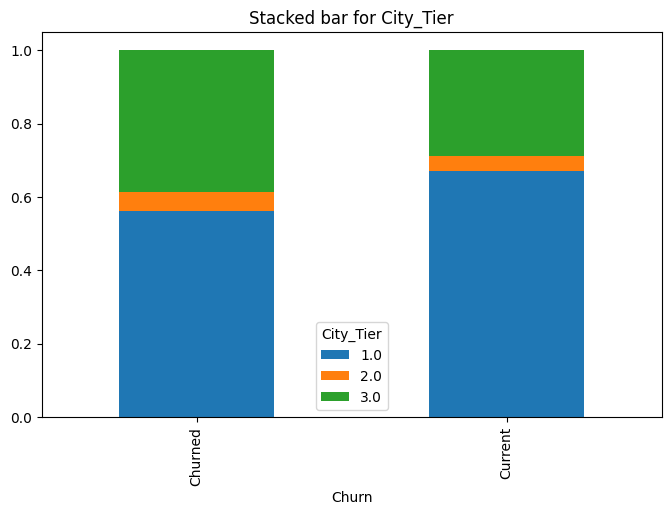

Payment  Cash on Delivery  Credit Card  Debit Card  E wallet       UPI
Churn                                                                 
Churned          0.135539     0.266275    0.374600  0.147279  0.076307
Current          0.081923     0.324674    0.418778  0.101434  0.073192


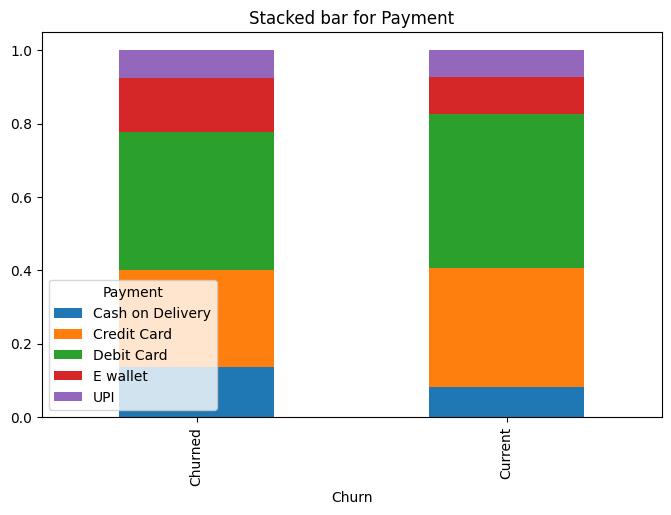

Gender     Female      Male
Churn                      
Churned  0.367663  0.632337
Current  0.405152  0.594848


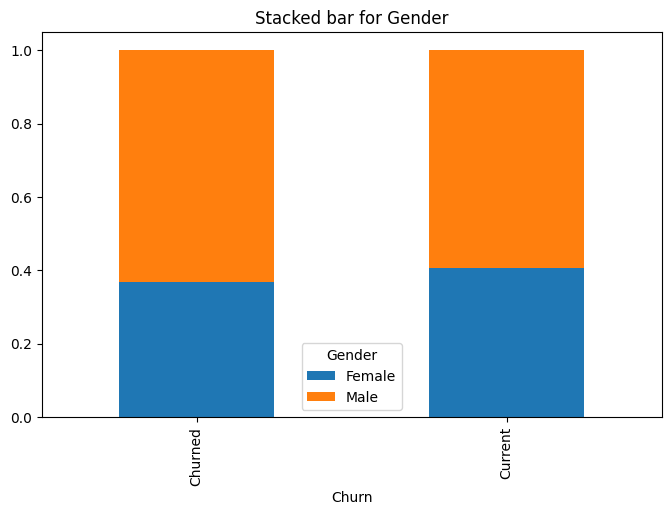

Service_Score       0.0       1.0       2.0       3.0       4.0       5.0
Churn                                                                    
Churned        0.000000  0.000000  0.292553  0.497872  0.209574  0.000000
Current        0.000862  0.008296  0.290993  0.490627  0.208683  0.000539


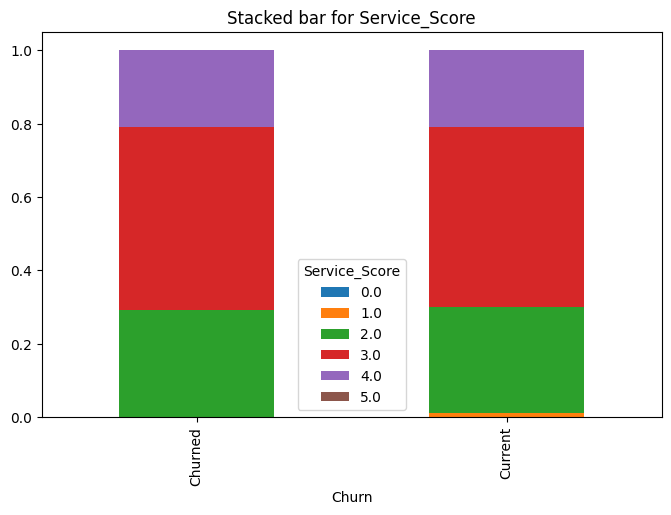

Account_user_count       1.0       2.0       3.0       4.0       5.0       6.0
Churn                                                                         
Churned             0.024044  0.026230  0.267213  0.414208  0.208743  0.059563
Current             0.044736  0.053194  0.308480  0.424104  0.146561  0.022925


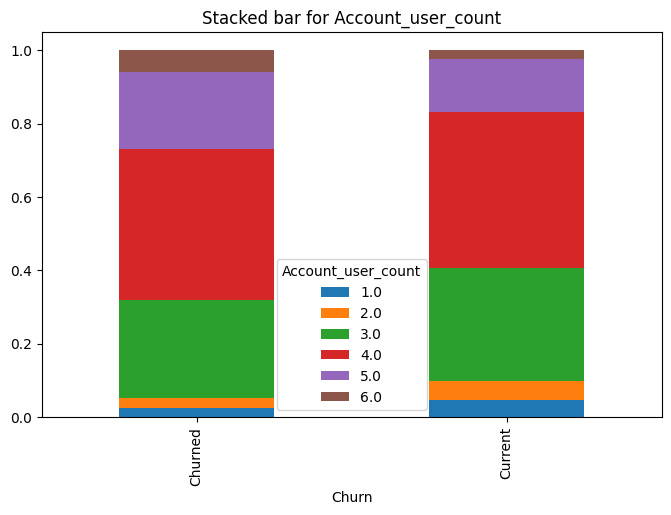

account_segment       HNI   Regular  Regular_Plus     Super  Super_Plus
Churn                                                                  
Churned          0.135783  0.021299      0.600106  0.221512    0.021299
Current          0.149058  0.051696      0.322779  0.392676    0.083791


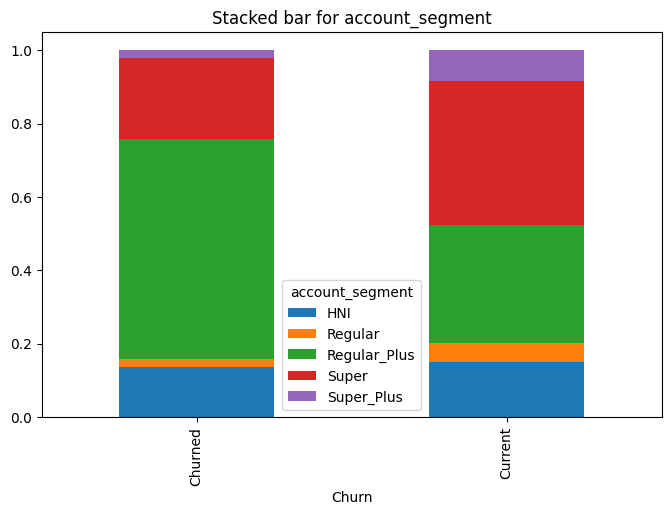

CC_Agent_Score       1.0       2.0       3.0       4.0       5.0
Churn                                                           
Churned         0.140875  0.078442  0.307898  0.194237  0.278549
Current         0.219849  0.109709  0.300216  0.190183  0.180043


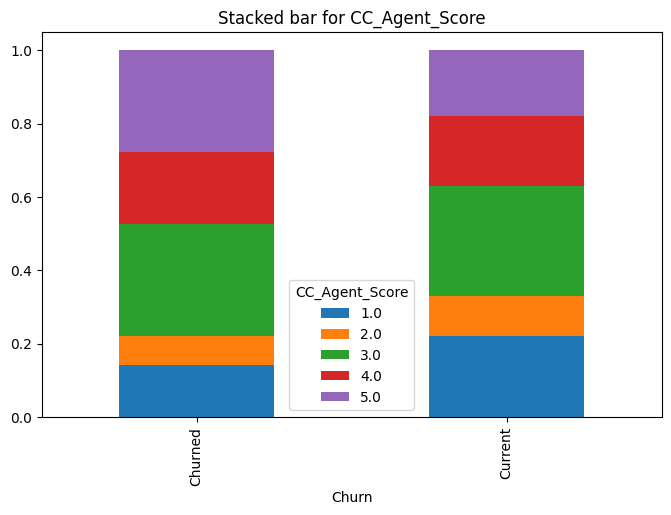

Marital_Status  Divorced   Married    Single
Churn                                       
Churned         0.130901  0.361052  0.508047
Current         0.155052  0.564787  0.280161


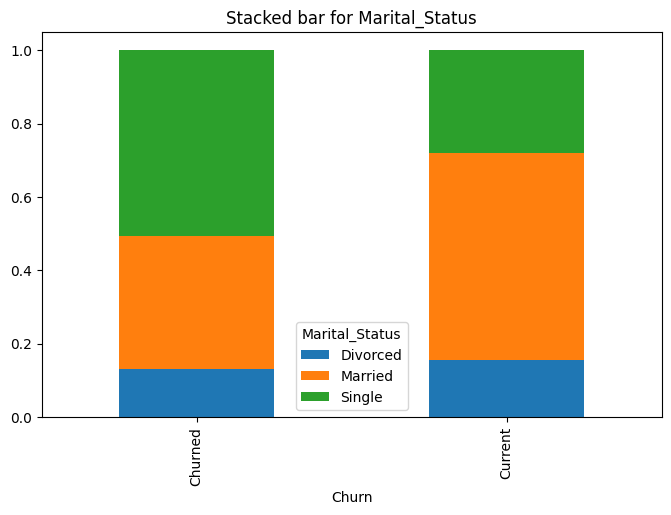

Complain_ly       0.0       1.0
Churn                          
Churned      0.462459  0.537541
Current      0.765803  0.234197


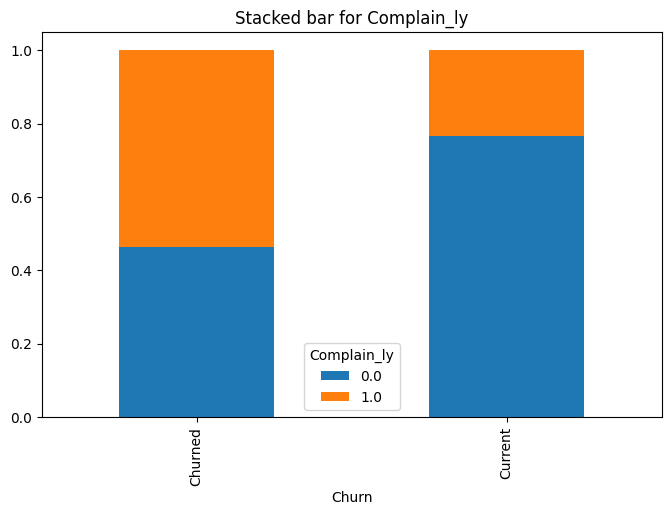

Login_device  Computer    Mobile
Churn                           
Churned       0.337479  0.662521
Current       0.277288  0.722712


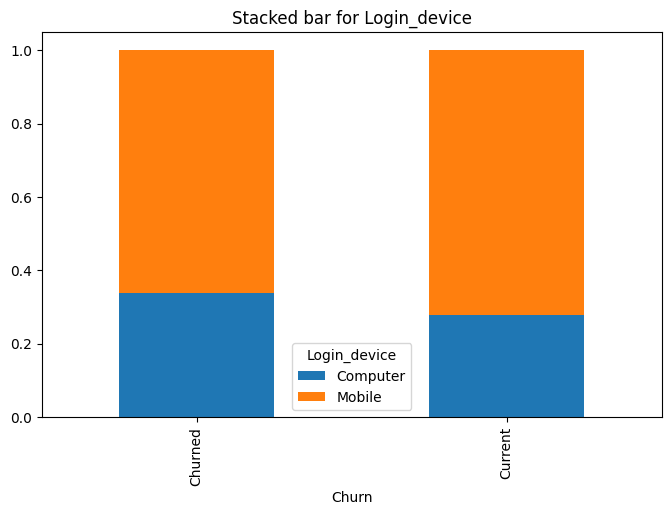

In [ ]:
for i in cat_cols:
    tab = pd.crosstab(CC['Churn'],CC[i],normalize='index')
    print(tab)
    #plt.figure(figsize=(12,6))
    tab.plot(kind='bar', stacked = True, figsize=(8,5))
    plot_title = "Stacked bar for " + i
    plt.title(plot_title)
    plt.show();


#### Correlation Matrix

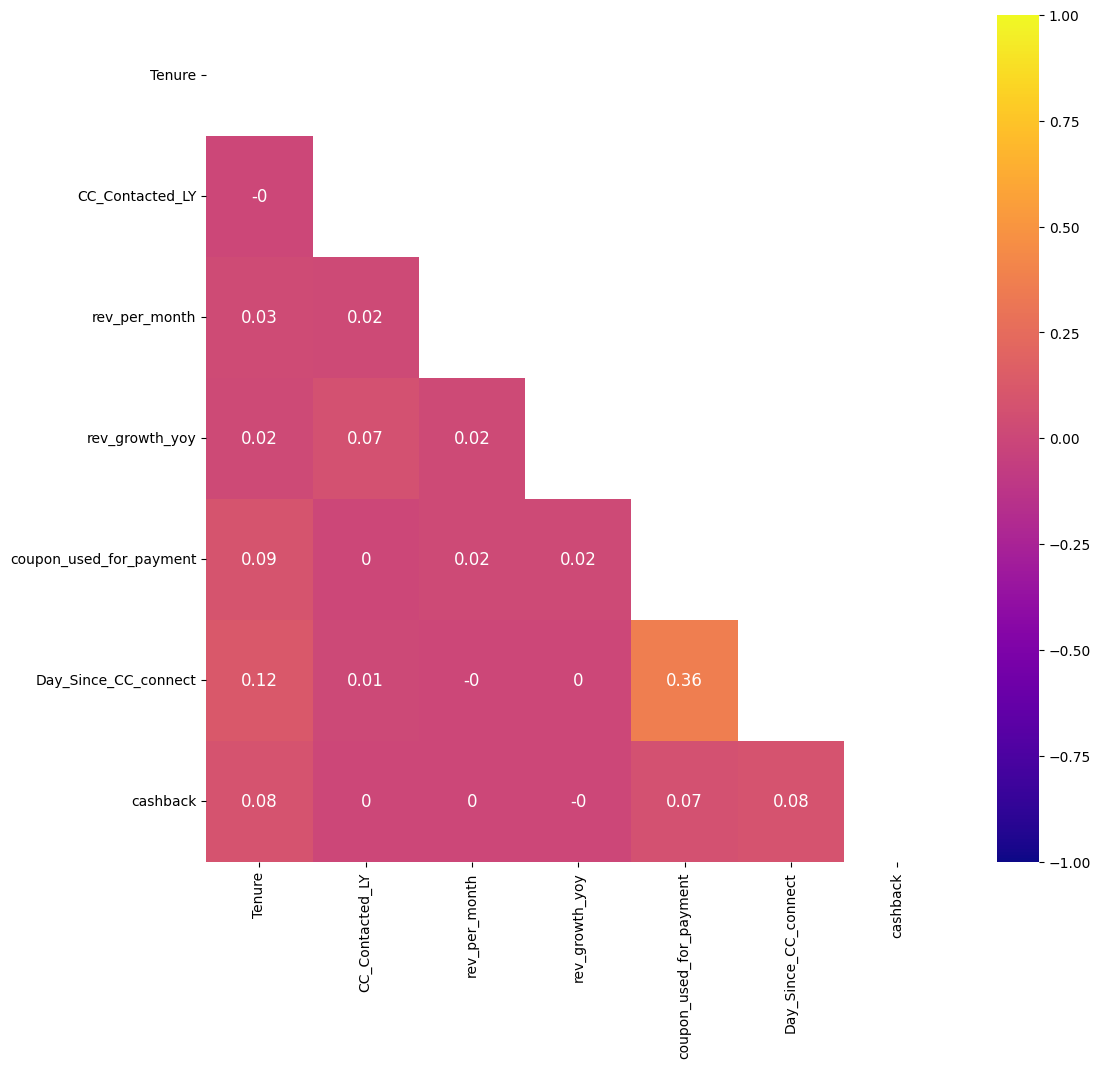

In [ ]:
CC_num = CC[num_cols]
corr = CC_num.corr()
mask = np.triu(np.ones_like(corr, dtype = np.bool))

plt.figure(figsize = (12,11))
sns.heatmap(round(corr,2), annot=True, mask=mask, cmap='plasma', vmin=-1, vmax=1, annot_kws={'size':12});

#### Replacing 0s and 1s in Target column 'Churn'

In [ ]:
CC['Churn'] = CC['Churn'].replace( {'Churned': 1, 'Current': 0} )

<ipython-input-80-16c730ac43b1>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  CC['Churn'] = CC['Churn'].replace( {'Churned': 1, 'Current': 0} )


In [ ]:
CC['Churn'].dtypes

dtype('int64')

### Removal of unwanted variables - Dropping AccountID

In [ ]:
CC.drop(["AccountID","rev_growth_yoy", "coupon_used_for_payment"], axis=1, inplace=True)

In [ ]:
CC.shape

(11260, 16)

## One hot/dummy encoding

In [ ]:
OneHotCols = ['Payment','Gender','account_segment','Marital_Status','Login_device']

In [ ]:
CC = pd.get_dummies(CC, columns=OneHotCols, drop_first=True) ### mass dummy encoding
CC.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,Day_Since_CC_connect,...,Payment_E wallet,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular_Plus,account_segment_Super,account_segment_Super_Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile
0,1,4.0,3.0,6.0,3.0,3.0,2.0,9.0,1.0,5.0,...,False,False,False,False,False,True,False,False,True,True
1,1,0.0,1.0,8.0,3.0,4.0,3.0,7.0,1.0,0.0,...,False,True,True,False,True,False,False,False,True,True
2,1,0.0,1.0,30.0,2.0,4.0,3.0,6.0,1.0,3.0,...,False,False,True,False,True,False,False,False,True,True
3,1,0.0,3.0,15.0,2.0,4.0,5.0,8.0,0.0,3.0,...,False,False,True,False,False,True,False,False,True,True
4,1,0.0,1.0,12.0,2.0,3.0,5.0,3.0,0.0,3.0,...,False,False,True,False,True,False,False,False,True,True


In [ ]:
CC.shape

(11260, 23)

In [ ]:
## Got to check if column names are ok after one hot encoding
CC.columns

Index(['Churn', 'Tenure', 'City_Tier', 'CC_Contacted_LY', 'Service_Score',
       'Account_user_count', 'CC_Agent_Score', 'rev_per_month', 'Complain_ly',
       'Day_Since_CC_connect', 'cashback', 'Payment_Credit Card',
       'Payment_Debit Card', 'Payment_E wallet', 'Payment_UPI', 'Gender_Male',
       'account_segment_Regular', 'account_segment_Regular_Plus',
       'account_segment_Super', 'account_segment_Super_Plus',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Login_device_Mobile'],
      dtype='object')

In [ ]:
## Blanks in 'Credit card', 'E wallet' and 'Debit card' to be removed; Super Plus and Regular Plus also shortened

CC.columns = ['Churn', 'Tenure', 'City_Tier', 'CC_Contacted_LY', 'Service_Score',
       'User_Count', 'CC_Score', 'Rev_Permonth', 'Complain_LY',
       'Days_Since_CC', 'Cashback', 'Payment_Creditcard',
       'Payment_Debitcard', 'Payment_Ewallet', 'Payment_UPI', 'Gender_Male',
       'ACSegment_Regular', 'ACSegment_Regularplus',
       'ACSegment_Super', 'ACSegment_Superplus',
       'Maritalstatus_Married', 'Maritalstatus_Single',
       'Logindevice_Mobile']

In [ ]:
CC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Churn                         11260 non-null  int64  
 1   Tenure                        11042 non-null  float64
 2   City_Tier                     11148 non-null  float64
 3   CC_Contacted_LY               11158 non-null  float64
 4   Service_Score                 11162 non-null  float64
 5   Account_user_count            10816 non-null  float64
 6   CC_Agent_Score                11144 non-null  float64
 7   rev_per_month                 10469 non-null  float64
 8   Complain_ly                   10903 non-null  float64
 9   Day_Since_CC_connect          10902 non-null  float64
 10  cashback                      10787 non-null  float64
 11  Payment_Credit Card           11260 non-null  bool   
 12  Payment_Debit Card            11260 non-null  bool   
 13  P

## Handling Missing Value

In [ ]:
X = CC.drop('Churn', axis=1)
y = CC['Churn']

X.shape, y.shape

((11260, 22), (11260,))

### Scaling before KNN imputing

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

In [ ]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,11042.0,-2.831360e-17,1.000045,-0.856038,-0.700749,-0.157237,0.386275,6.830775
City_Tier,11148.0,3.728628e-17,1.000045,-0.714697,-0.714697,-0.714697,1.471157,1.471157
CC_Contacted_LY,11158.0,-9.169937e-17,1.000045,-1.566394,-0.775691,-0.210902,0.579802,12.892189
Service_Score,11162.0,-1.425923e-16,1.000045,-4.000444,-1.243919,0.134344,0.134344,2.890870
Account_user_count,10816.0,1.261318e-16,1.000046,-2.632502,-0.677332,0.300253,0.300253,2.255423
CC_Agent_Score,11144.0,-1.836291e-16,1.000045,-1.497773,-0.772983,-0.048194,0.676596,1.401386
rev_per_month,10469.0,-5.429689e-18,1.000048,-0.450293,-0.282355,-0.114416,0.053522,11.221437
Complain_ly,10903.0,-7.168642e-18,1.000046,-0.631867,-0.631867,-0.631867,1.582612,1.582612
Day_Since_CC_connect,10902.0,-4.692632e-17,1.000046,-1.253070,-0.712160,-0.441704,0.910573,11.458334
cashback,10787.0,1.185665e-16,1.000046,-1.098427,-0.274423,-0.173445,0.021123,10.079715


### KNN imputing

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer()
X = pd.DataFrame(imputer.fit_transform(X), columns = X.columns)


In [ ]:
X.isnull().sum()

,0
Tenure,0
City_Tier,0
CC_Contacted_LY,0
Service_Score,0
Account_user_count,0
CC_Agent_Score,0
rev_per_month,0
Complain_ly,0
Day_Since_CC_connect,0
cashback,0


In [ ]:
X_inverse_with_outlier = pd.DataFrame(scaler.inverse_transform(X), columns=X.columns)

In [ ]:
X_inverse_with_outlier.head()

,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,Day_Since_CC_connect,cashback,...,Payment_E wallet,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular_Plus,account_segment_Super,account_segment_Super_Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile
0,4.0,3.0,6.0,3.0,3.0,2.0,9.0,1.0,5.0,159.930,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.0,1.0,8.0,3.0,4.0,3.0,7.0,1.0,0.0,120.900,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
2,0.0,1.0,30.0,2.0,4.0,3.0,6.0,1.0,3.0,126.272,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
3,0.0,3.0,15.0,2.0,4.0,5.0,8.0,0.0,3.0,134.070,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,0.0,1.0,12.0,2.0,3.0,5.0,3.0,0.0,3.0,129.600,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
## Writing the null treated dataset separately for models that are outlier resistant

CC_with_outlier = pd.concat([round(X_inverse_with_outlier,0),y], axis=1)
CC_with_outlier.to_csv("CC_with_outlier.csv")

## Outlier treatment

In [ ]:
Outlier_treat_vars = ['Tenure', 'CC_Contacted_LY', 'rev_per_month', 'Day_Since_CC_connect', 'cashback']

<Axes: >

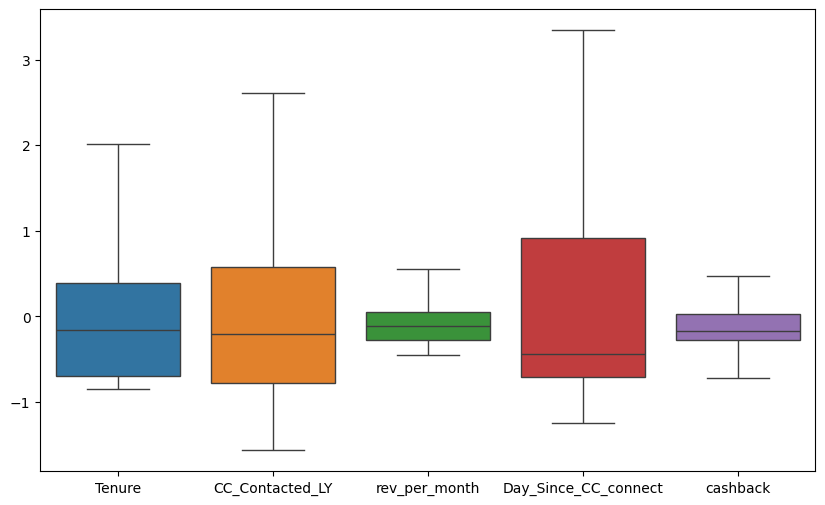

In [ ]:
Outlier_treat_vars = ['Tenure', 'CC_Contacted_LY', 'rev_per_month', 'Day_Since_CC_connect', 'cashback']
plt.figure(figsize=(10, 6))
sns.boxplot(data=X[Outlier_treat_vars])

In [ ]:
def out_limit(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [ ]:
for column in Outlier_treat_vars:
    lr,ur = out_limit(X[column])
    X[column] = np.where(X[column] > ur, ur, X[column])
    X[column] = np.where(X[column] < lr, lr, X[column])

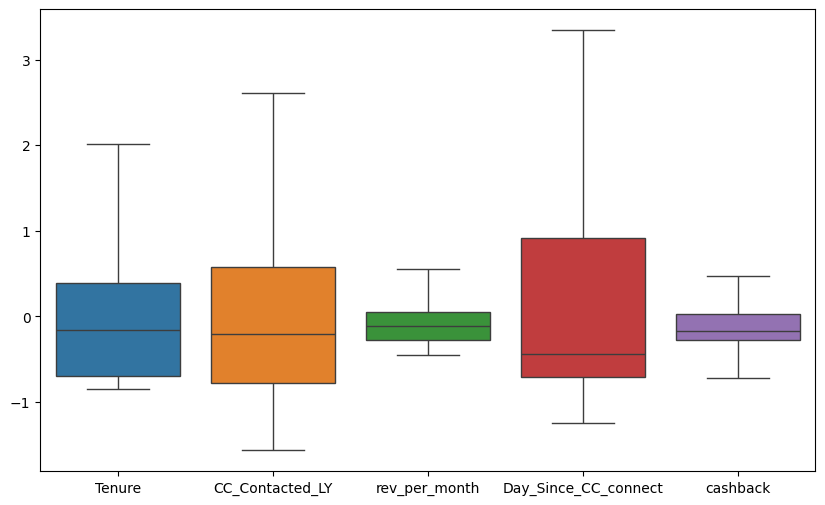

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data = X[Outlier_treat_vars]);

In [ ]:
num_cols = ['Tenure', 'CC_Contacted_LY', 'rev_per_month', 'Day_Since_CC_connect', 'cashback']  # Updated num_cols
cols = ['Skewness']
pd.DataFrame(X[num_cols].skew().round(2), columns=cols)

,Skewness
Tenure,0.80
CC_Contacted_LY,0.80
rev_per_month,0.78
Day_Since_CC_connect,0.82
cashback,0.93


In [ ]:
X_inverse_without_outlier = pd.DataFrame(scaler.inverse_transform(X), columns=X.columns)

In [ ]:
X_inverse_without_outlier.columns

Index(['Tenure', 'City_Tier', 'CC_Contacted_LY', 'Service_Score',
       'Account_user_count', 'CC_Agent_Score', 'rev_per_month', 'Complain_ly',
       'Day_Since_CC_connect', 'cashback', 'Payment_Credit Card',
       'Payment_Debit Card', 'Payment_E wallet', 'Payment_UPI', 'Gender_Male',
       'account_segment_Regular', 'account_segment_Regular_Plus',
       'account_segment_Super', 'account_segment_Super_Plus',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Login_device_Mobile'],
      dtype='object')

In [ ]:
df_total = pd.concat([round(X_inverse_without_outlier,0),y],axis=1)

In [ ]:
df_total.to_csv('CC_without_outlier.csv', index=False)

## Bivariate graphs after outlier & missing value treatment

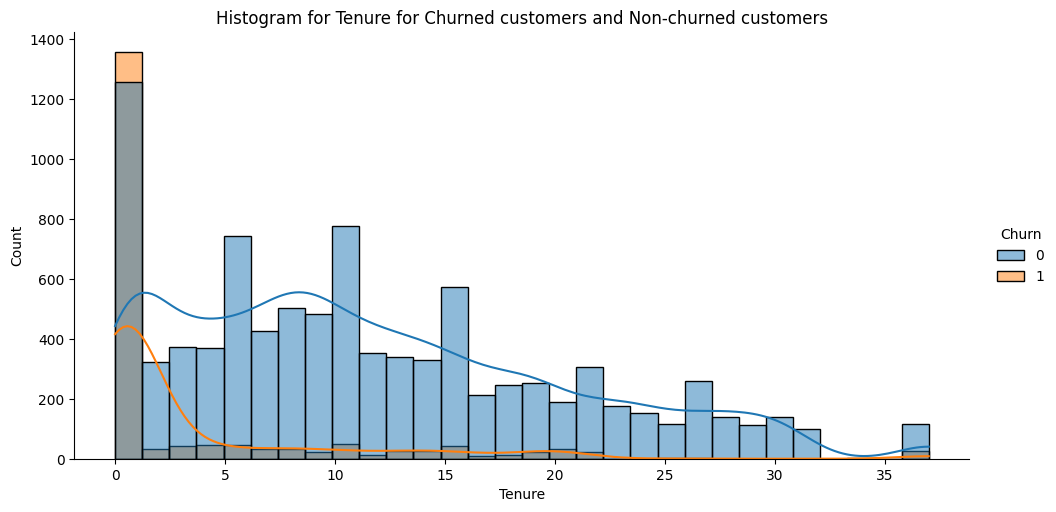

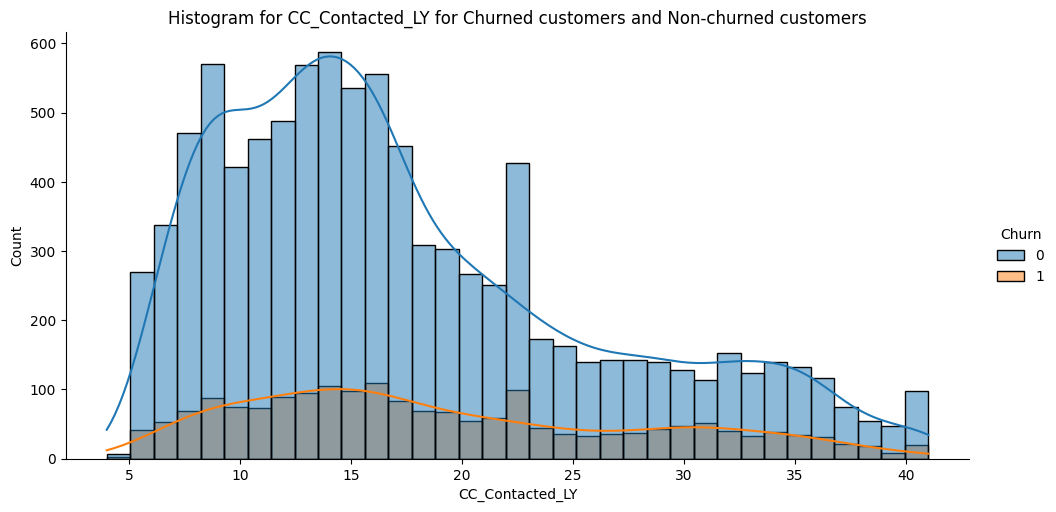

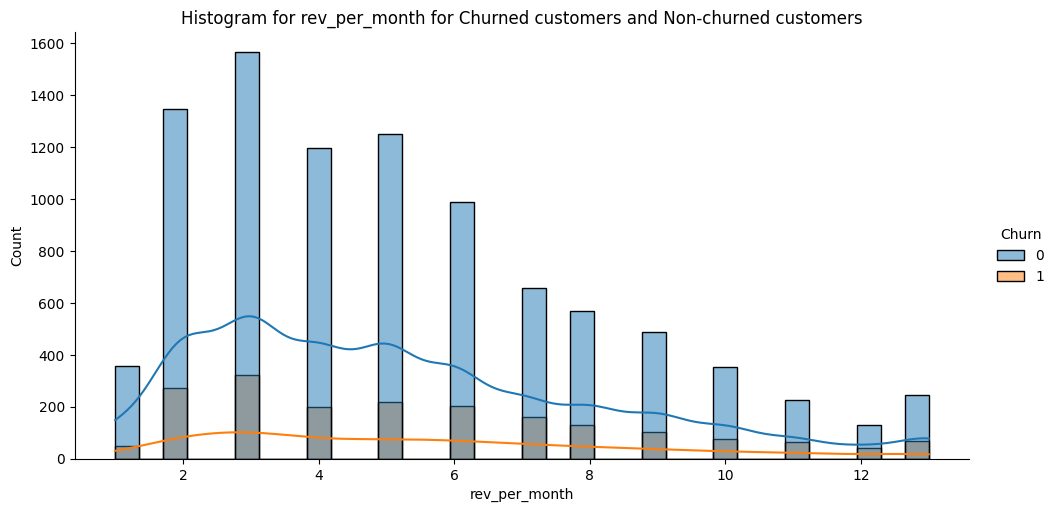

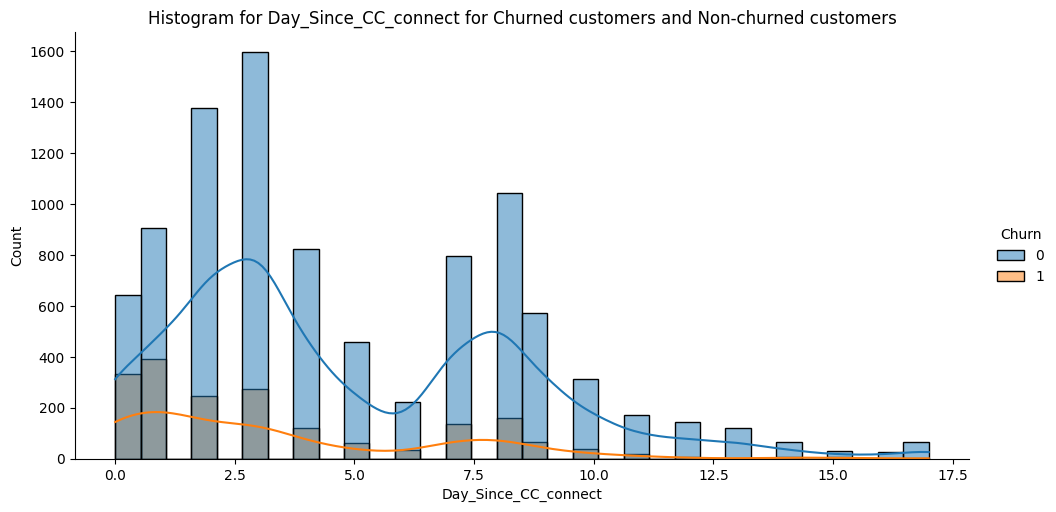

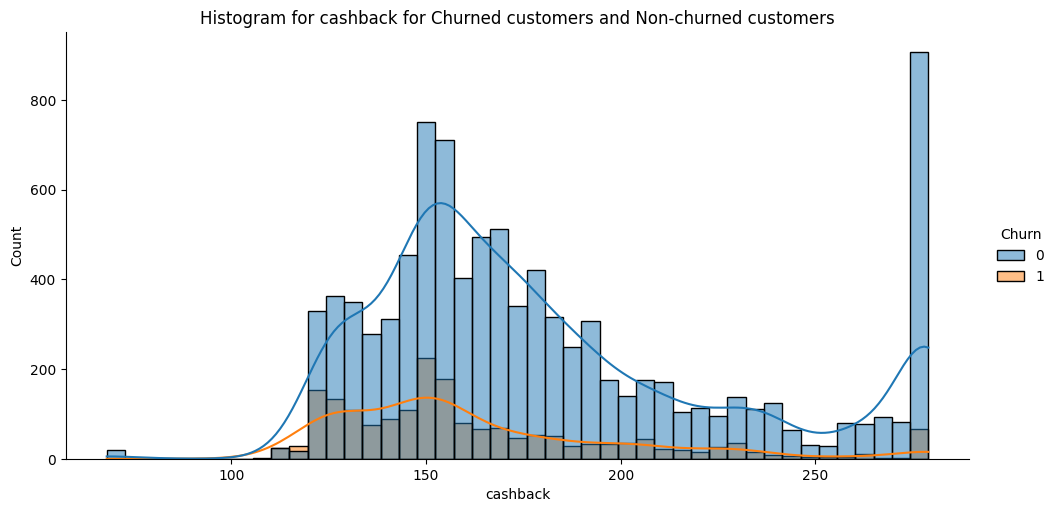

In [ ]:
for i in num_cols:
    sns.displot(x=df_total[i], hue=df_total['Churn'], kind='hist', kde=True, aspect=2)
    plot_title = "Histogram for " + i + " for Churned customers and Non-churned customers"
    plt.title(plot_title)
    plt.show();

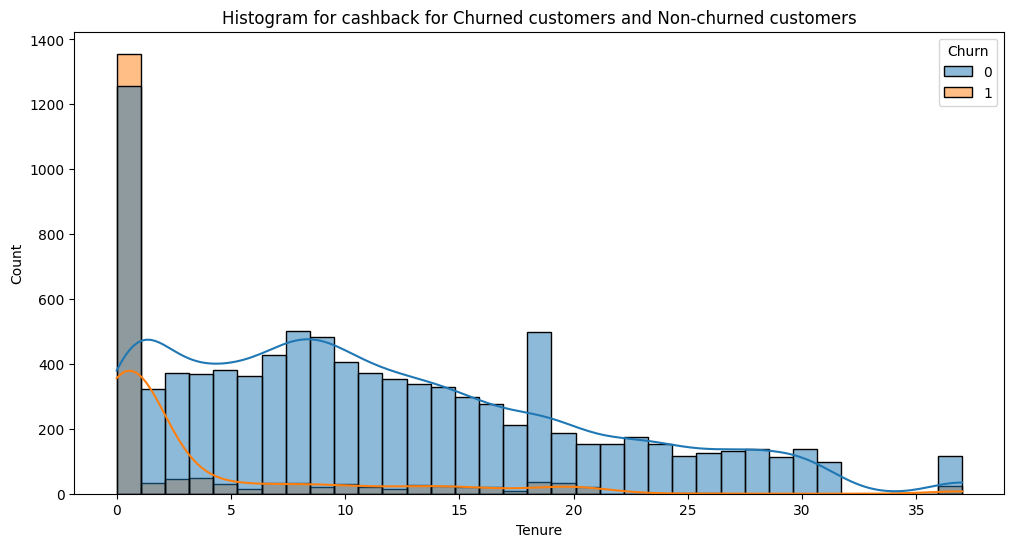

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(x=df_total['Tenure'], kde=True, bins = 35, hue=df_total['Churn'])
plot_title = "Histogram for " + i + " for Churned customers and Non-churned customers"
plt.title(plot_title)
plt.show();

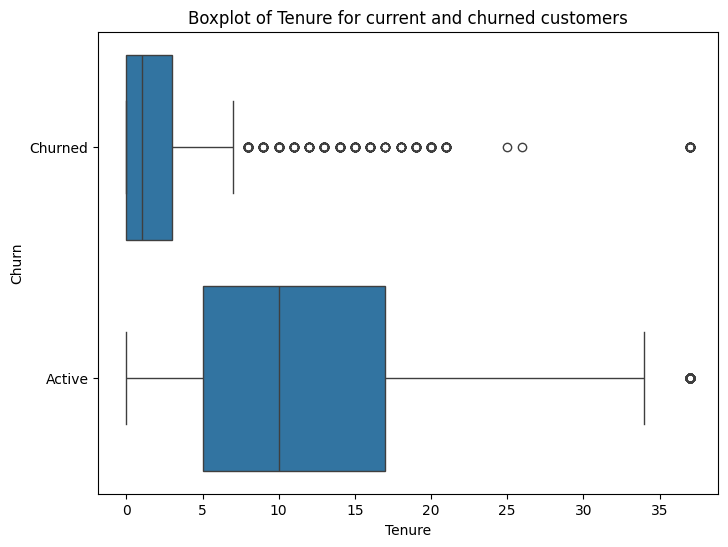

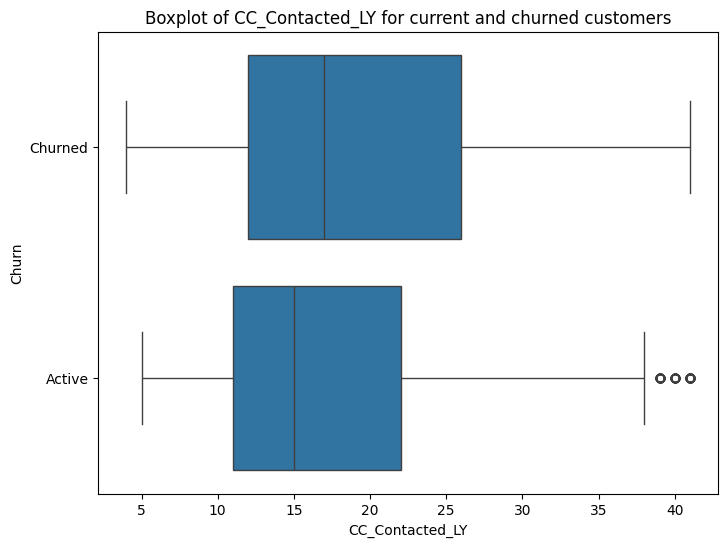

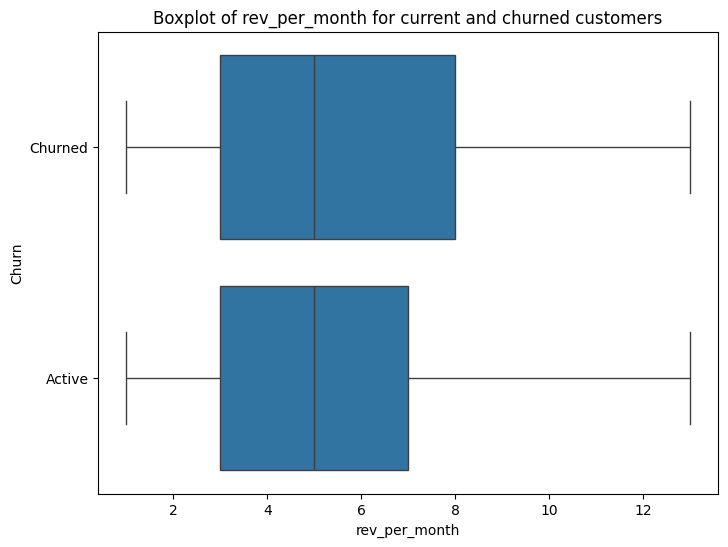

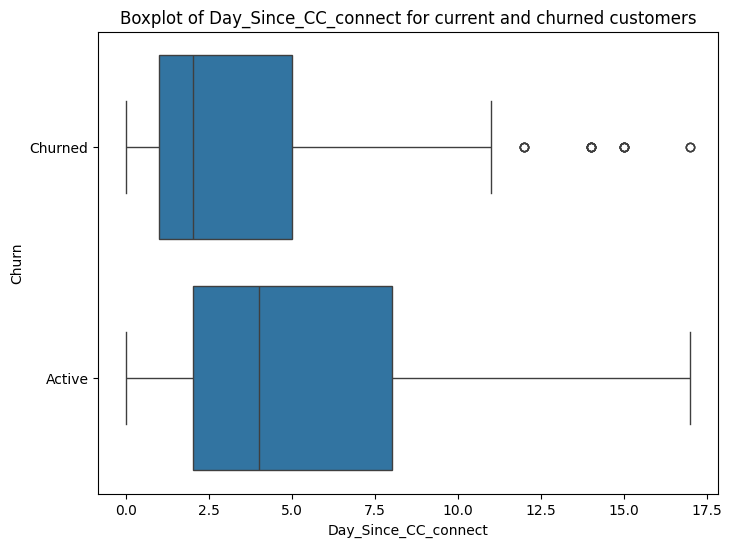

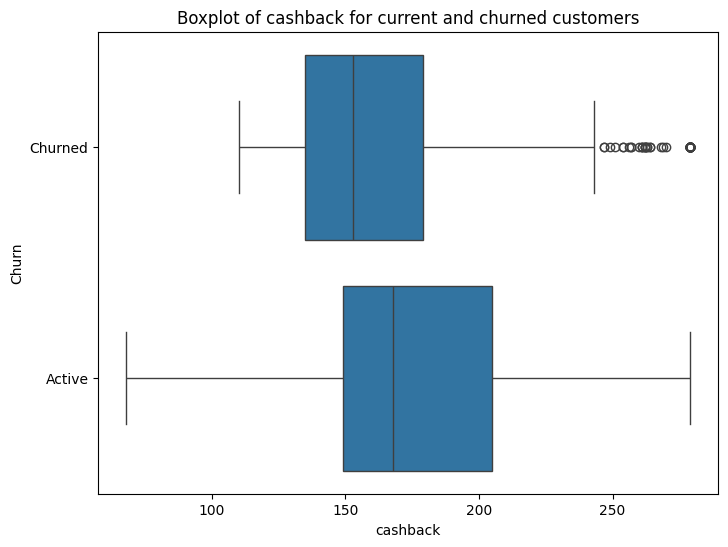

In [ ]:
df_total_churn = df_total['Churn'].replace( {1: 'Churned', 0: 'Active'} ) ## y needs to be categorical
for i in num_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df_total[i], y=df_total_churn)
    plot_title = 'Boxplot of ' + i + " for current and churned customers"
    plt.title(plot_title)
    plt.show();

## Analysis of key variables to gain further insights

### Cashback and Coupon used for payment variables against Churn and Tenure (low and high bins)

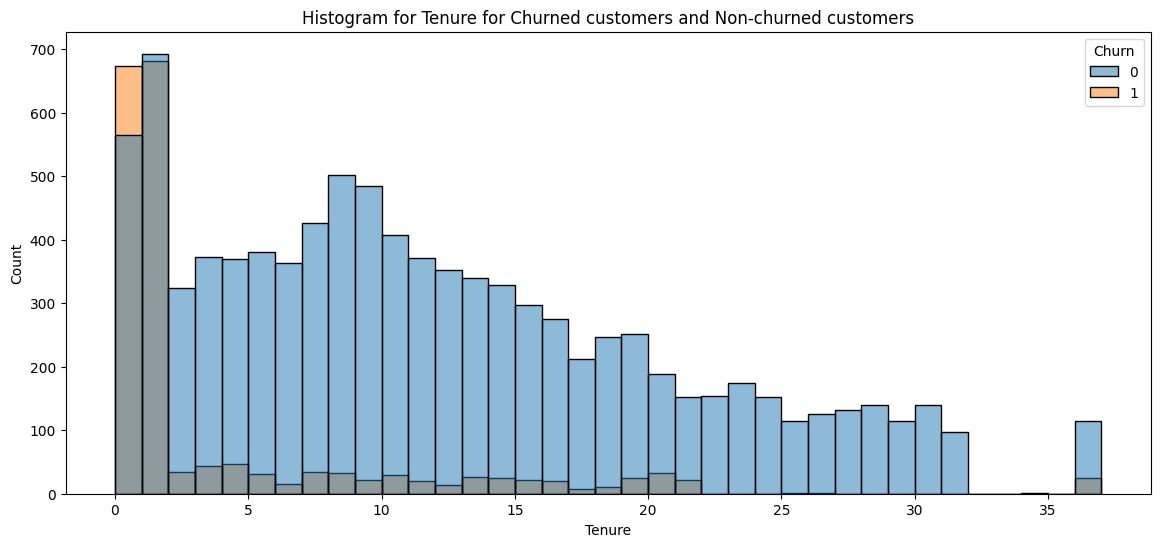

In [ ]:
plt.figure(figsize=(14,6))
sns.histplot(x=df_total['Tenure'], bins = 37, hue=df_total['Churn'])
plot_title = "Histogram for " + "Tenure" + " for Churned customers and Non-churned customers"
plt.title(plot_title)
plt.show();

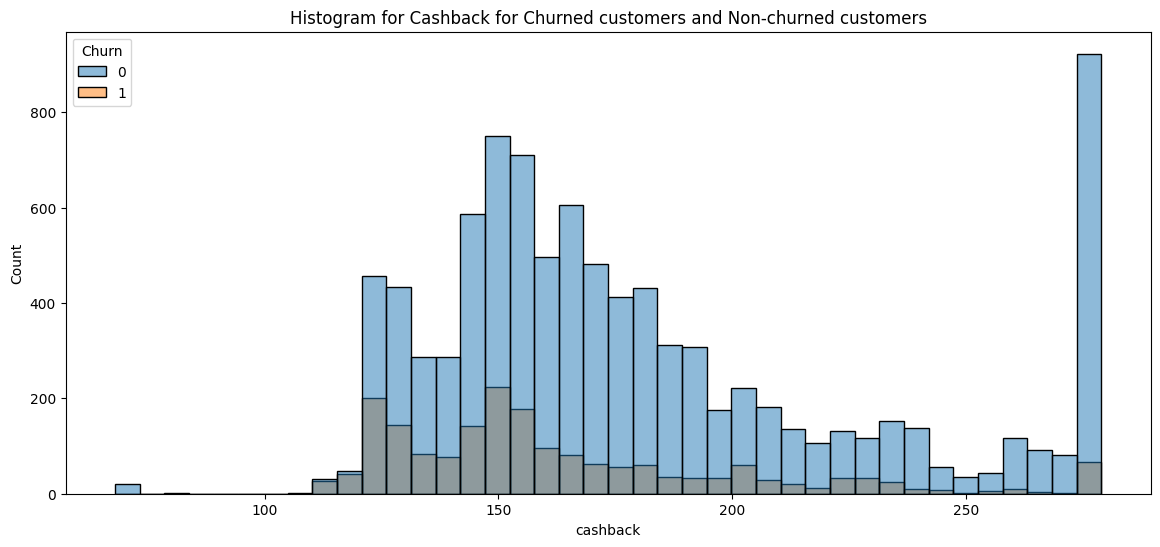

In [ ]:
### Cashback histplot wrt churn

plt.figure(figsize=(14,6))
sns.histplot(x=df_total['cashback'], bins = 40, hue=df_total['Churn'])
plot_title = "Histogram for " + "Cashback" + " for Churned customers and Non-churned customers"
plt.title(plot_title)
plt.show();

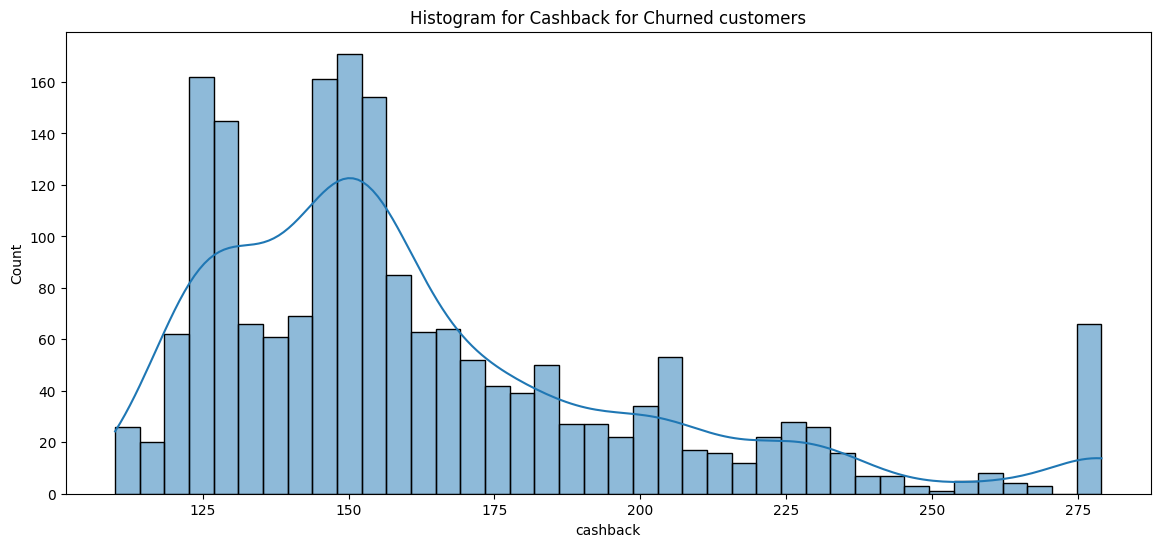

In [ ]:
### Cashback offers for only churned customers

plt.figure(figsize=(14,6))
sns.histplot(x=df_total[df_total['Churn']==1]['cashback'], kde=True, bins = 40)
plot_title = "Histogram for " + "Cashback" + " for Churned customers"
plt.title(plot_title)
plt.show();

In [ ]:
### MEDIAN CASHBACK FOR CHURNED AND NON-CHURNED CUSTOMERS

df_total[df_total['Churn']==1]['cashback'].median(), df_total[df_total['Churn']==0]['cashback'].median()

(153.0, 168.0)

In [ ]:
### Statistical description of cashback for churned customers

pd.DataFrame(df_total[df_total['Churn']==1]['cashback'].describe() )

,cashback
count,1896.000000
mean,163.103376
std,38.422260
min,110.000000
25%,135.000000
50%,153.000000
75%,179.000000
max,279.000000


In [ ]:
### Statistical description of cashback for active customers

pd.DataFrame(df_total[df_total['Churn']==0]['cashback'].describe() )

,cashback
count,9364.000000
mean,181.617044
std,46.632509
min,68.000000
25%,149.000000
50%,168.000000
75%,205.000000
max,279.000000


In [ ]:
df_temp=df_total.copy()

In [ ]:
df_temp['Tenure_bin'] = np.where(df_temp['Tenure'] <= 2 , 'Tenure<=2', 'Other_Tenure')

In [ ]:
df_temp['Tenure_bin'].value_counts()

,count
Tenure_bin,
Other_Tenure,8288
Tenure<=2,2972


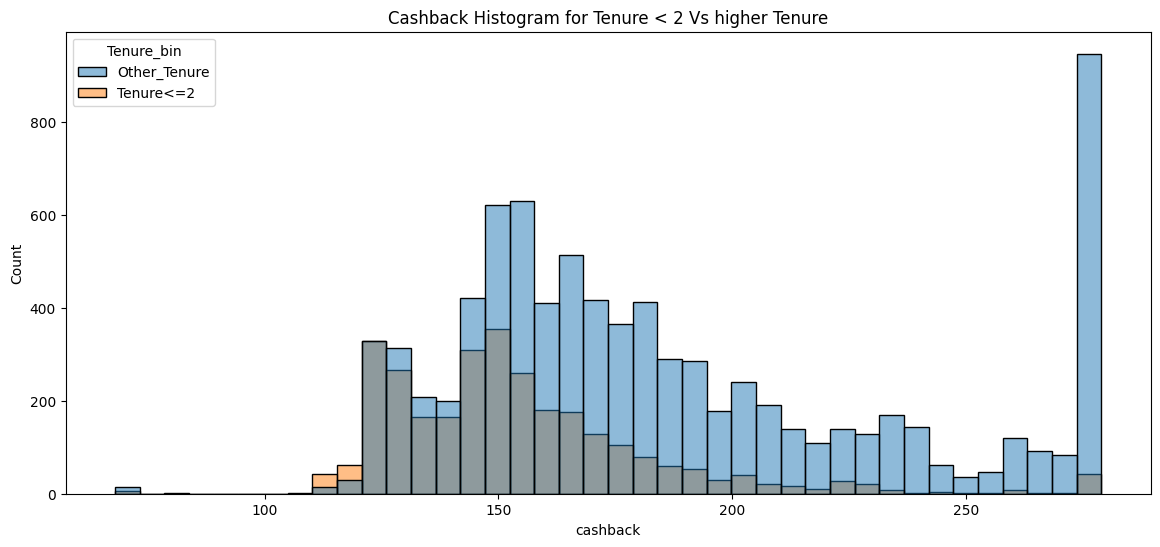

In [ ]:
## Histplot of cashback with Tenure as hue

plt.figure(figsize=(14,6))
sns.histplot(x=df_temp['cashback'], bins = 40, hue=df_temp['Tenure_bin'])
plot_title = "Cashback Histogram" + " for Tenure < 2 Vs higher Tenure"
plt.title(plot_title)
plt.show();

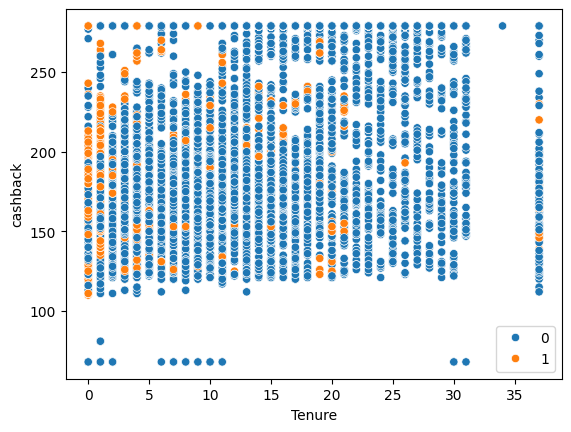

In [ ]:
### Scatter plot of Tenure and Cashback

sns.scatterplot(x=df_total['Tenure'], y=df_total['cashback'], hue=df_total['Churn'])
plt.legend(loc='lower right');

In [ ]:
CC_predictor.columns

Index(['Tenure', 'City_Tier', 'CC_Contacted_LY', 'Payment', 'Gender',
       'Service_Score', 'Account_user_count', 'account_segment',
       'CC_Agent_Score', 'Marital_Status', 'rev_per_month', 'Complain_ly',
       'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect',
       'cashback', 'Login_device'],
      dtype='object')

In [ ]:
CC_temp = CC_predictor.copy()
CC_temp['Churn'] = df_total['Churn']

In [ ]:
CC_temp.coupon_used_for_payment.value_counts()

,count
coupon_used_for_payment,
1.0,4373
2.0,2656
0.0,2150
3.0,698
4.0,424
5.0,284
6.0,234
7.0,184
8.0,88


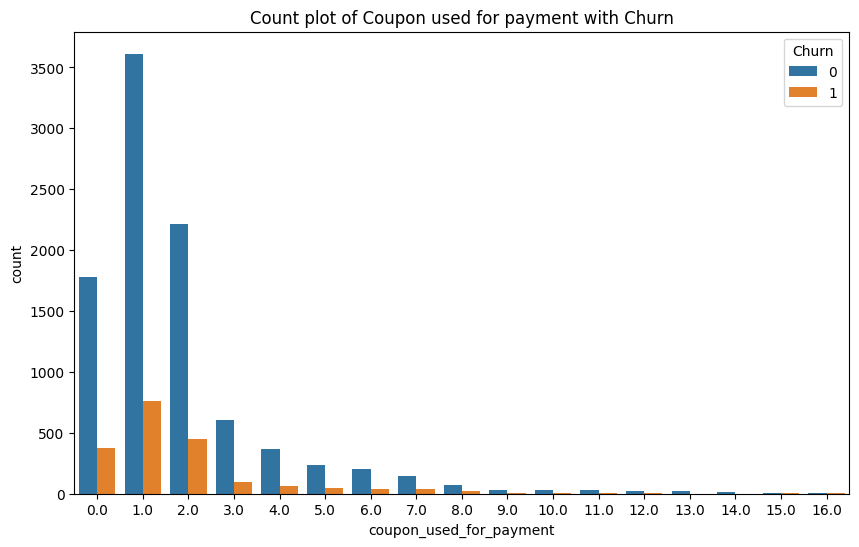

In [ ]:
### Distribution of coupon_used_for_payment by churn

plt.figure(figsize=(10,6))
sns.countplot(data = CC_temp, x='coupon_used_for_payment', hue='Churn')
plot_title = "Count plot of "+"Coupon used for payment"+" with Churn"
plt.title(plot_title)
plt.show();


In [ ]:
CC_temp['Tenure_bin'] = df_temp['Tenure_bin']

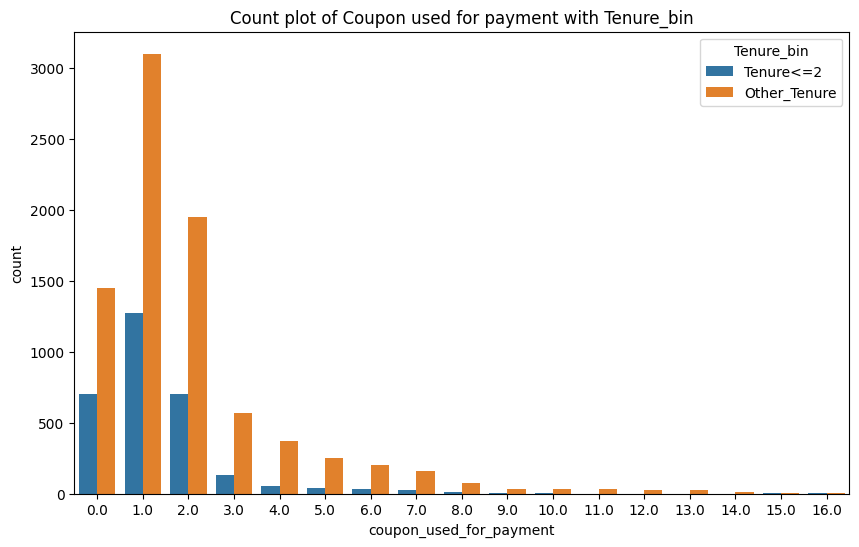

In [ ]:
### Distribution of coupon_used_for_payment by tenure bin

plt.figure(figsize=(10,6))
sns.countplot(data = CC_temp, x='coupon_used_for_payment', hue='Tenure_bin')
plot_title = "Count plot of "+"Coupon used for payment"+" with Tenure_bin"
plt.title(plot_title)
plt.show();


### Days since customer care contact, CC contacted last year, Complaint raised last year

In [ ]:
CC_temp.columns

Index(['Tenure', 'City_Tier', 'CC_Contacted_LY', 'Payment', 'Gender',
       'Service_Score', 'Account_user_count', 'account_segment',
       'CC_Agent_Score', 'Marital_Status', 'rev_per_month', 'Complain_ly',
       'rev_growth_yoy', 'coupon_used_for_payment', 'Day_Since_CC_connect',
       'cashback', 'Login_device', 'Churn', 'Tenure_bin'],
      dtype='object')

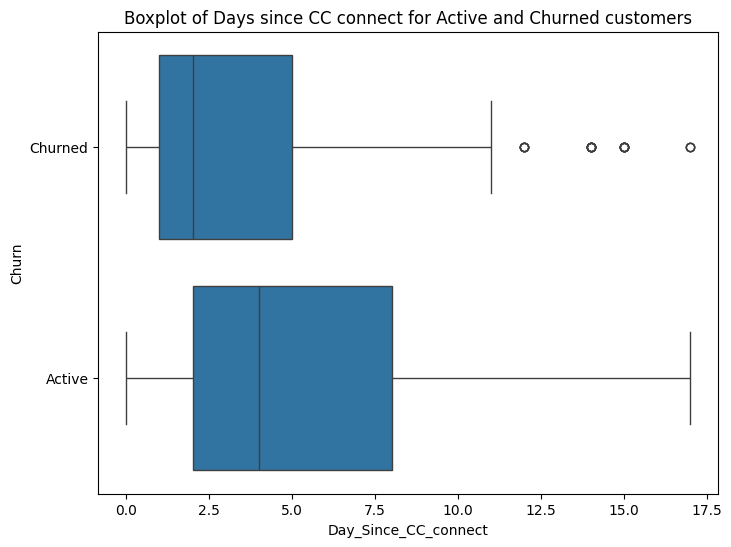

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df_total["Day_Since_CC_connect"], y=df_total_churn)
plot_title = 'Boxplot of ' + "Days since CC connect" + " for Active and Churned customers"
plt.title(plot_title)
plt.show();

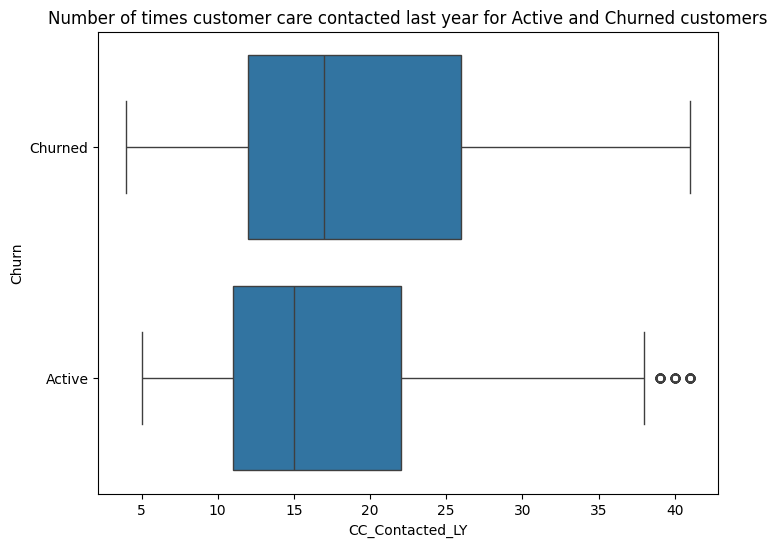

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df_total["CC_Contacted_LY"], y=df_total_churn)
plot_title = 'Number of times ' + "customer care contacted last year" + " for Active and Churned customers"
plt.title(plot_title)
plt.show();

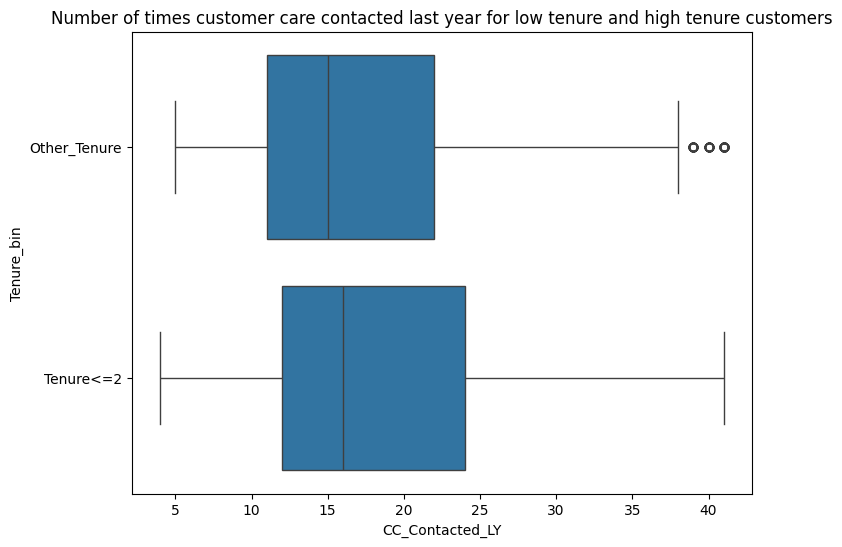

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df_temp["CC_Contacted_LY"], y=df_temp['Tenure_bin'])
plot_title = 'Number of times ' + "customer care contacted last year" + " for low tenure and high tenure customers"
plt.title(plot_title)
plt.show();

Complain_ly       0.0       1.0
Churn                          
0            0.765592  0.234408
1            0.464135  0.535865


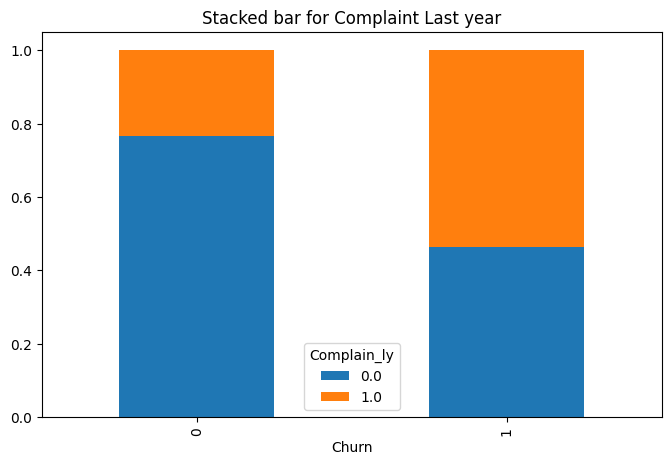

In [ ]:
tab = pd.crosstab(df_temp['Churn'],df_temp['Complain_ly'],normalize='index')
print(tab)

tab.plot(kind='bar', stacked = True, figsize=(8,5))
plot_title = "Stacked bar for " + "Complaint Last year"
plt.title(plot_title)
plt.show();

In [ ]:
Churn_count = df_temp[df_temp['Churn']==0]['Churn'].count()
Active_count = df_temp[df_temp['Churn']==1]['Churn'].count()

In [ ]:
Churn_count, Active_count

(np.int64(9364), np.int64(1896))

In [ ]:
Churn_complaint = df_temp[(df_temp['Churn']==0) & (df_temp['Complain_ly']==1)]['Churn'].count()
Active_complaint = df_temp[(df_temp['Churn']==1) & (df_temp['Complain_ly']==1)]['Churn'].count()

In [ ]:
Churn_complaint, Active_complaint

(np.int64(2195), np.int64(1016))

In [ ]:
tab = pd.crosstab(df_temp['Churn'],df_temp['Complain_ly'],normalize='index', margins=True)
print(tab)

Complain_ly       0.0       1.0
Churn                          
0            0.765592  0.234408
1            0.464135  0.535865
All          0.714831  0.285169


In [ ]:
tab = pd.crosstab(df_temp['Complain_ly'],df_temp['Churn'],normalize='index')
print(tab)

Churn               0         1
Complain_ly                    
0.0          0.890670  0.109330
1.0          0.683588  0.316412


Text(0.5, 1.0, '%Churn for customers with and without complaint')

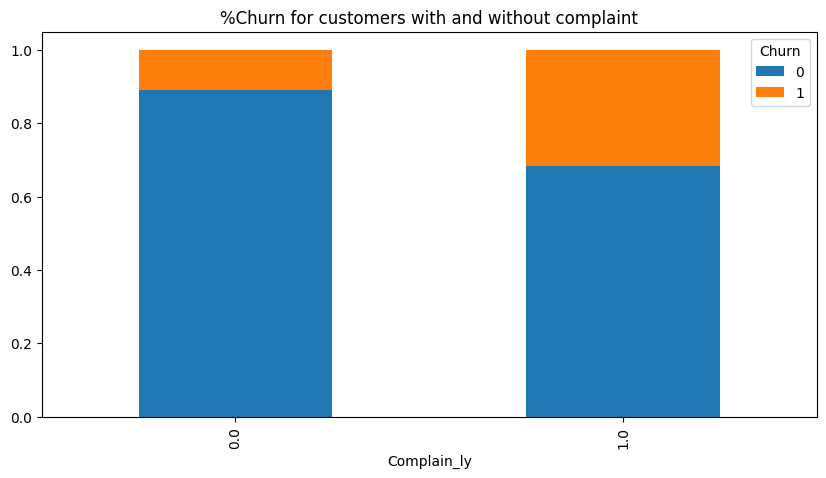

In [ ]:
tab.plot(kind='bar', stacked = True, figsize=(10,5))
plt.title("%Churn for customers with and without complaint")

### Revenue per month

In [ ]:
tab = pd.crosstab(df_temp['rev_per_month'],df_temp['Churn'],normalize='index', margins=False).round(2)*100
print(tab)

Churn             0     1
rev_per_month            
1.0            88.0  12.0
2.0            83.0  17.0
3.0            83.0  17.0
4.0            86.0  14.0
5.0            85.0  15.0
6.0            83.0  17.0
7.0            80.0  20.0
8.0            82.0  18.0
9.0            83.0  17.0
10.0           82.0  18.0
11.0           78.0  22.0
12.0           77.0  23.0
13.0           79.0  21.0


In [ ]:
df_revenue_pm = pd.DataFrame(tab.astype('int64'), columns=['Active','Churned'])

In [ ]:
df_revenue_pm['Active'] = tab[0]
df_revenue_pm['Churned'] = tab[1]

In [ ]:
df_revenue_pm

,Active,Churned
rev_per_month,,
1.0,88.0,12.0
2.0,83.0,17.0
3.0,83.0,17.0
4.0,86.0,14.0
5.0,85.0,15.0
6.0,83.0,17.0
7.0,80.0,20.0
8.0,82.0,18.0
9.0,83.0,17.0


<Axes: xlabel='rev_per_month'>

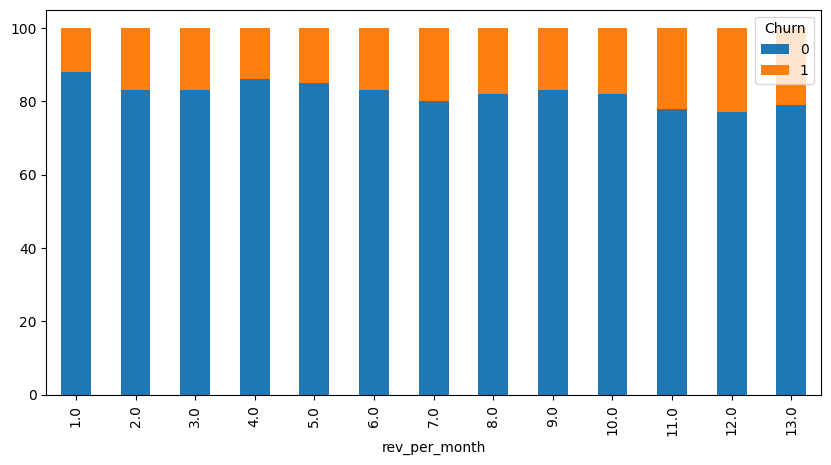

In [ ]:
tab.plot(kind='bar', stacked = True, figsize=(10,5))

In [ ]:
df_temp['Rev_low_high'] = np.where(df_temp['rev_per_month'] <= 6 , 'Low Revenue', 'High Revenue')

Churn                0         1
Rev_low_high                    
High Revenue  0.807214  0.192786
Low Revenue   0.841728  0.158272


<Axes: xlabel='Rev_low_high'>

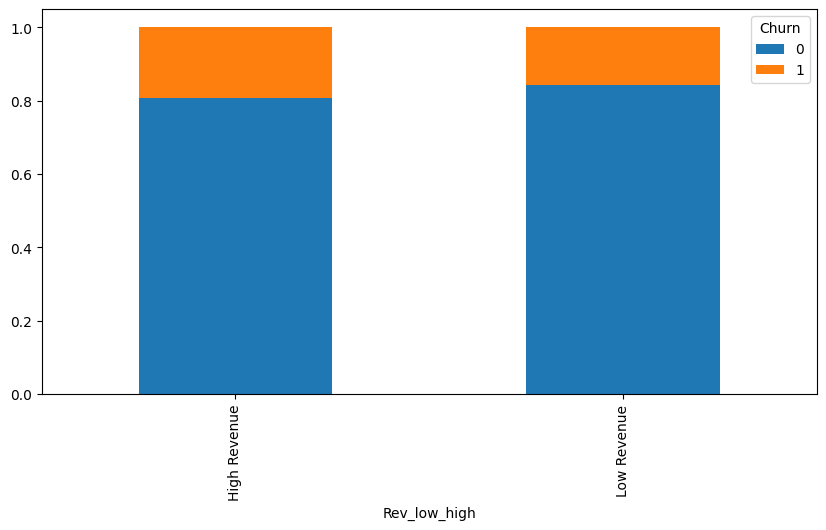

In [ ]:
tab_revenue = pd.crosstab(df_temp['Rev_low_high'],df_temp['Churn'],normalize='index')
print(tab_revenue)
tab_revenue.plot(kind='bar', stacked = True, figsize=(10,5))

Rev_low_high  High Revenue  Low Revenue
Churn                                  
0                 0.284387     0.715613
1                 0.335443     0.664557


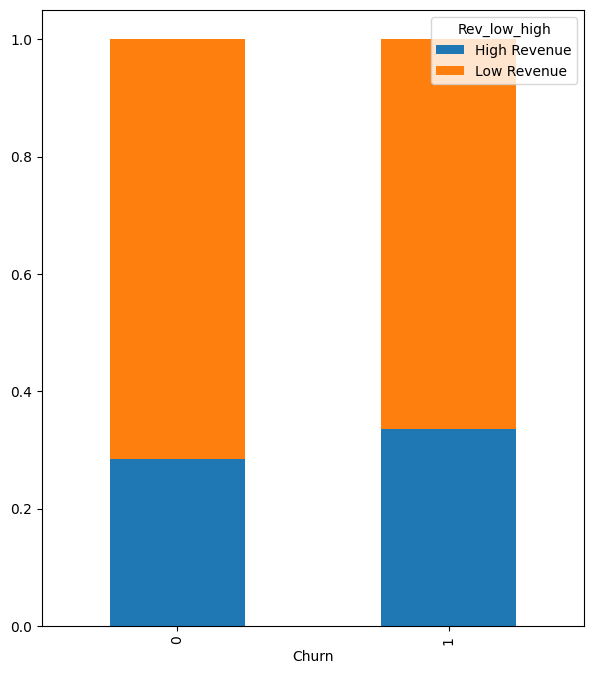

In [ ]:
tab_revenue2 = pd.crosstab(df_temp['Churn'],df_temp['Rev_low_high'],normalize='index') #, margins=True)
print(tab_revenue2)
tab_revenue2.plot(kind='bar', stacked = True, figsize=(7,8));

In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
sns.set_style("white")

In [ ]:
df = pd.read_csv("CC_without_outlier.csv")

In [ ]:
df.head(5)

,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,Day_Since_CC_connect,cashback,...,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular_Plus,account_segment_Super,account_segment_Super_Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile,Churn
0,4.0,3.0,6.0,3.0,3.0,2.0,9.0,1.0,5.0,160.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
1,0.0,1.0,8.0,3.0,4.0,3.0,7.0,1.0,0.0,121.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
2,0.0,1.0,30.0,2.0,4.0,3.0,6.0,1.0,3.0,126.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
3,0.0,3.0,15.0,2.0,4.0,5.0,8.0,0.0,3.0,134.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
4,0.0,1.0,12.0,2.0,3.0,5.0,3.0,0.0,3.0,130.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1


In [ ]:
df_outlier = pd.read_csv("CC_with_outlier.csv")

In [ ]:
df_outlier.head(5)

,Unnamed: 0,Tenure,City_Tier,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_per_month,Complain_ly,Day_Since_CC_connect,...,Payment_UPI,Gender_Male,account_segment_Regular,account_segment_Regular_Plus,account_segment_Super,account_segment_Super_Plus,Marital_Status_Married,Marital_Status_Single,Login_device_Mobile,Churn
0,0,4.0,3.0,6.0,3.0,3.0,2.0,9.0,1.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
1,1,0.0,1.0,8.0,3.0,4.0,3.0,7.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
2,2,0.0,1.0,30.0,2.0,4.0,3.0,6.0,1.0,3.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1
3,3,0.0,3.0,15.0,2.0,4.0,5.0,8.0,0.0,3.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
4,4,0.0,1.0,12.0,2.0,3.0,5.0,3.0,0.0,3.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1


Machine Leraning Algorithm

Logistic Regression Model - SKLearn

LR_model1 : Base model with outlier treated unscaled data

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
LR_model1 = LogisticRegression(verbose=True,n_jobs=-1,random_state=123)

LR_model1.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


LogisticRegression(n_jobs=-1, random_state=123, verbose=True)

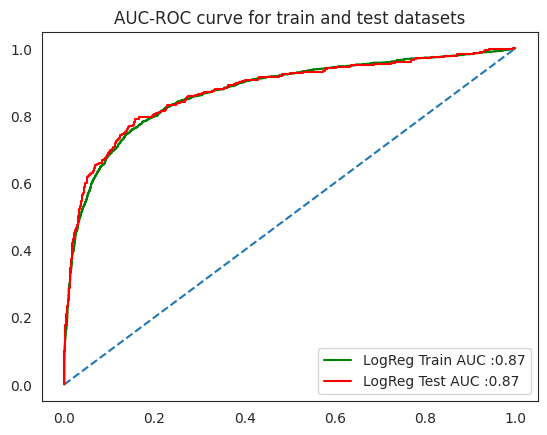

In [ ]:
### Predicting on train and test dataset

LR_model1_ytrain_pred = LR_model1.predict(X_train)
LR_model1_ytest_pred = LR_model1.predict(X_test)

## Predicting probabilities on train dataset
LR_model1_trainprobs = LR_model1.predict_proba(X_train)
# # keep probabilities for the positive outcome only
LR_model1_trainprobs = LR_model1_trainprobs[:, 1]

## Predicting probabilities on test dataset
LR_model1_testprobs = LR_model1.predict_proba(X_test)
# # keep probabilities for the positive outcome only
LR_model1_testprobs = LR_model1_testprobs[:, 1]


# # calculate roc curve
train_auc = round(roc_auc_score(y_train, LR_model1_trainprobs),2)
test_auc = round(roc_auc_score(y_test, LR_model1_testprobs),2)
train_label_LR = 'LogReg Train AUC :' + str(train_auc)
test_label_LR = 'LogReg Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(y_train, LR_model1_trainprobs)
fpr_test_LR, tpr_test_LR, thresholds_test_LR = roc_curve(y_test, LR_model1_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label_LR)
plt.plot(fpr_test_LR, tpr_test_LR, color='red', label=test_label_LR)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay # Added plot_roc_curve to the imports

def model_eval(model,xtrue,ytrue,ypred,probs):

    plot_roc_curve(model,xtrue,ytrue,color='red') # Now plot_roc_curve should be recognized.
    plt.plot([0, 1], [0, 1], linestyle='--');

    print('Accuracy : ', model.score(xtrue, ytrue))

    # Instead of plot_confusion_matrix, use ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_estimator(model, xtrue, ytrue, colorbar=False).plot();

    print(classification_report(ytrue, ypred));

    # # calculate AUC
    auc = roc_auc_score(ytrue, probs)
    print('AUC: %.3f' % auc);

In [ ]:
from sklearn.metrics import accuracy_score
log_acc = accuracy_score(y_train, LR_model1_ytrain_pred)

In [ ]:
print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_train, LR_model1_ytrain_pred))


Model Performance:
Logistic Regression Accuracy: 0.8868

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93      7491
           1       0.76      0.48      0.59      1517

    accuracy                           0.89      9008
   macro avg       0.83      0.73      0.76      9008
weighted avg       0.88      0.89      0.88      9008



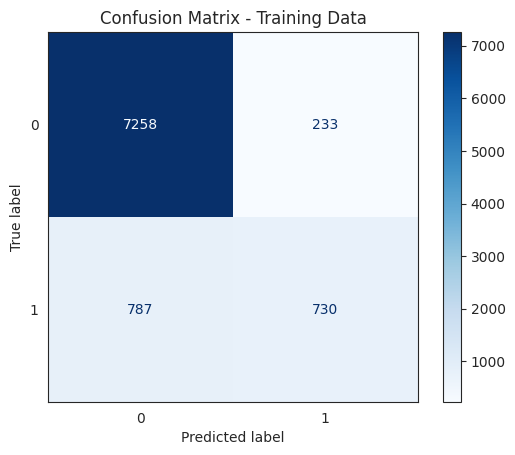

In [ ]:
cm = confusion_matrix(y_train, LR_model1_ytrain_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - Training Data")
plt.show()

In [ ]:
log_acc = accuracy_score(y_test, LR_model1_ytest_pred)

In [ ]:
print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_test, LR_model1_ytest_pred))


Model Performance:
Logistic Regression Accuracy: 0.8908

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94      1873
           1       0.75      0.53      0.62       379

    accuracy                           0.89      2252
   macro avg       0.83      0.75      0.78      2252
weighted avg       0.88      0.89      0.88      2252



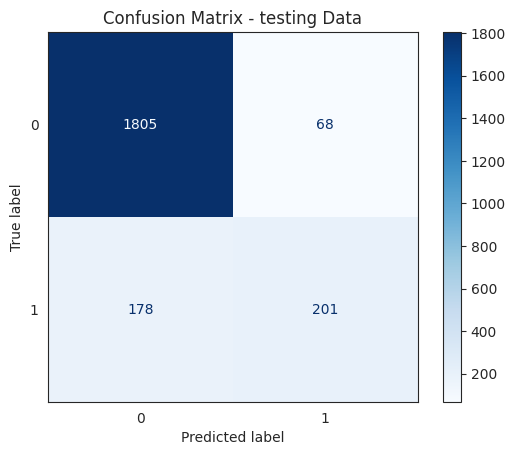

In [ ]:
cm = confusion_matrix(y_test, LR_model1_ytest_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - testing Data")
plt.show()

LR_model2 : Iteration 1 - features to select = 8

In [ ]:
from sklearn.feature_selection import RFE
LogR = LogisticRegression(random_state=123, max_iter=1000)
LR_model2 = RFE(estimator = LogR, n_features_to_select=8, step=1)
LR_model2 = LR_model2.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
LR_model2.ranking_

array([ 8,  1, 14, 10,  6,  7,  9,  1, 12, 15,  1,  1, 11,  4,  5,  1, 13,
        1,  1,  3,  1,  2])

In [ ]:
selected_cols = pd.DataFrame({'Feature': X.columns, 'Rank': LR_model2.ranking_})
selected_cols[selected_cols['Rank'] == 1]

,Feature,Rank
1,City_Tier,1
7,Complain_ly,1
10,Payment_Credit Card,1
11,Payment_Debit Card,1
15,account_segment_Regular,1
17,account_segment_Super,1
18,account_segment_Super_Plus,1
20,Marital_Status_Single,1


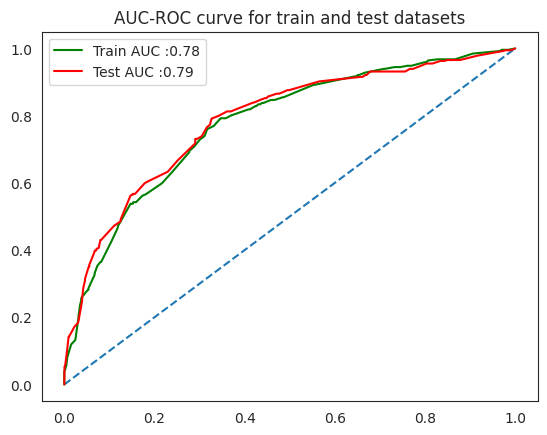

In [ ]:
### Predicting on train and test dataset

LR_model2_ytrain_pred = LR_model2.predict(X_train)
LR_model2_ytest_pred = LR_model2.predict(X_test)

## Predicting probabilities on train dataset
LR_model2_trainprobs = LR_model2.predict_proba(X_train)
# # keep probabilities for the positive outcome only
LR_model2_trainprobs = LR_model2_trainprobs[:, 1]

## Predicting probabilities on test dataset
LR_model2_testprobs = LR_model2.predict_proba(X_test)
# # keep probabilities for the positive outcome only
LR_model2_testprobs = LR_model2_testprobs[:, 1]


# # calculate roc curve
train_auc = round(roc_auc_score(y_train, LR_model2_trainprobs),2)
test_auc = round(roc_auc_score(y_test, LR_model2_testprobs),2)
train_label = 'Train AUC :' + str(train_auc)
test_label = 'Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(y_train, LR_model2_trainprobs)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, LR_model2_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label)
plt.plot(fpr_test, tpr_test, color='red', label=test_label)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();

In [ ]:
LogR = LogisticRegression(random_state=123, max_iter=1000)
LR_model3 = RFE(estimator = LogR, n_features_to_select=12, step=1)
LR_model3 = LR_model3.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
selected_cols = pd.DataFrame({'Feature': X.columns, 'Rank': LR_model3.ranking_})
selected_cols[selected_cols['Rank'] == 1]

,Feature,Rank
1,City_Tier,1
7,Complain_ly,1
10,Payment_Credit Card,1
11,Payment_Debit Card,1
13,Payment_UPI,1
14,Gender_Male,1
15,account_segment_Regular,1
17,account_segment_Super,1
18,account_segment_Super_Plus,1
19,Marital_Status_Married,1


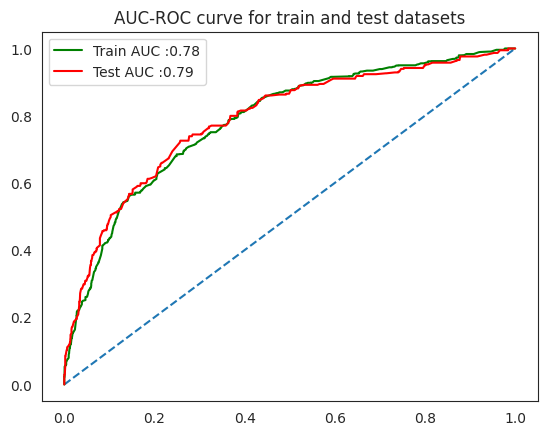

In [ ]:
### Predicting on train and test dataset

LR_model3_ytrain_pred = LR_model3.predict(X_train)
LR_model3_ytest_pred = LR_model3.predict(X_test)

## Predicting probabilities on train dataset
LR_model3_trainprobs = LR_model3.predict_proba(X_train)
# # keep probabilities for the positive outcome only
LR_model3_trainprobs = LR_model3_trainprobs[:, 1]

## Predicting probabilities on test dataset
LR_model3_testprobs = LR_model3.predict_proba(X_test)
# # keep probabilities for the positive outcome only
LR_model3_testprobs = LR_model3_testprobs[:, 1]


# # calculate roc curve
train_auc = round(roc_auc_score(y_train, LR_model3_trainprobs),2)
test_auc = round(roc_auc_score(y_test, LR_model3_testprobs),2)
train_label = 'Train AUC :' + str(train_auc)
test_label = 'Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(y_train, LR_model3_trainprobs)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, LR_model3_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label)
plt.plot(fpr_test, tpr_test, color='red', label=test_label)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();

LR_model4 : Iteration 3 - features to select = 16

In [ ]:
LogR = LogisticRegression(random_state=123, max_iter=1000)
LR_model4 = RFE(estimator = LogR, n_features_to_select=16, step=1)
LR_model4 = LR_model4.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
selected_cols = pd.DataFrame({'Feature': X.columns, 'Rank': LR_model4.ranking_})
selected_cols[selected_cols['Rank'] == 1]

,Feature,Rank
0,Tenure,1
1,City_Tier,1
4,Account_user_count,1
5,CC_Agent_Score,1
6,rev_per_month,1
7,Complain_ly,1
10,Payment_Credit Card,1
11,Payment_Debit Card,1
13,Payment_UPI,1
14,Gender_Male,1


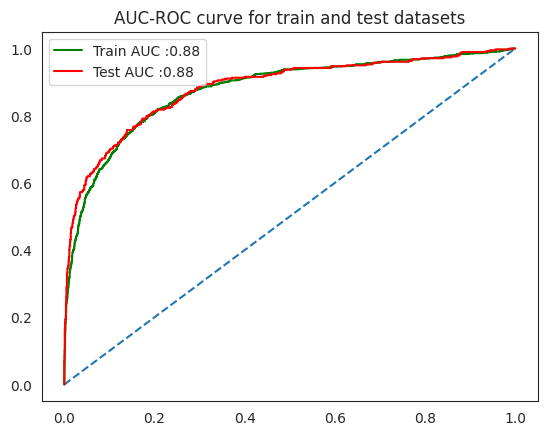

In [ ]:
### Predicting on train and test dataset

LR_model4_ytrain_pred = LR_model4.predict(X_train)
LR_model4_ytest_pred = LR_model4.predict(X_test)

## Predicting probabilities on train dataset
LR_model4_trainprobs = LR_model4.predict_proba(X_train)
# # keep probabilities for the positive outcome only
LR_model4_trainprobs = LR_model4_trainprobs[:, 1]

## Predicting probabilities on test dataset
LR_model4_testprobs = LR_model4.predict_proba(X_test)
# # keep probabilities for the positive outcome only
LR_model4_testprobs = LR_model4_testprobs[:, 1]


# # calculate roc curve
train_auc = round(roc_auc_score(y_train, LR_model4_trainprobs),2)
test_auc = round(roc_auc_score(y_test, LR_model4_testprobs),2)
train_label = 'Train AUC :' + str(train_auc)
test_label = 'Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(y_train, LR_model4_trainprobs)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, LR_model4_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label)
plt.plot(fpr_test, tpr_test, color='red', label=test_label)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();

Support vector machine classifier

In [ ]:
from sklearn import svm

In [ ]:
def model_eval1(model,xtrue,ytrue,ypred):

    plot_roc_curve(model,xtrue,ytrue,color='red')
    plt.plot([0, 1], [0, 1], linestyle='--');

    print('Accuracy : ', model.score(xtrue, ytrue))

    plot_confusion_matrix(model,xtrue,ytrue, colorbar=False);

    print(classification_report(ytrue, ypred));

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

SVM_model1 : Default base model

In [ ]:
## Creating model and fitting train dataset

SVM_model1 = svm.SVC(random_state=1, probability=True)
SVM_model1.fit(X_train, y_train)

SVC(probability=True, random_state=1)

In [ ]:
### Predicting on train and test dataset

SVM_model1_ytrain_pred = SVM_model1.predict(X_train)
SVM_model1_ytest_pred = SVM_model1.predict(X_test)

In [ ]:
## Predicting probabilities on train dataset
SVM_model1_trainprobs = SVM_model1.predict_proba(X_train)
# # keep probabilities for the positive outcome only
SVM_model1_trainprobs = SVM_model1_trainprobs[:, 1]

## Predicting probabilities on test dataset
SVM_model1_testprobs = SVM_model1.predict_proba(X_test)
# # keep probabilities for the positive outcome only
SVM_model1_testprobs = SVM_model1_testprobs[:, 1]

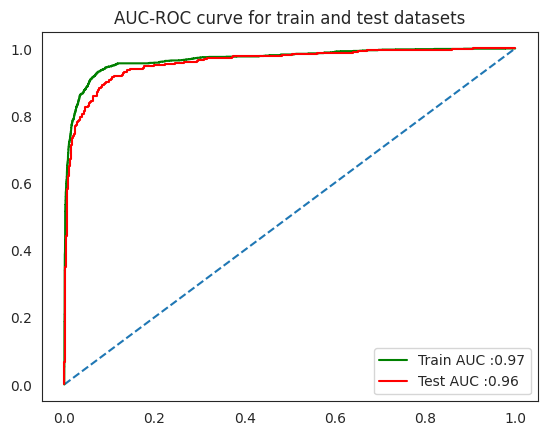

In [ ]:
# # calculate roc curve
train_auc = round(roc_auc_score(y_train, SVM_model1_trainprobs),2)
test_auc = round(roc_auc_score(y_test, SVM_model1_testprobs),2)
train_label = 'Train AUC :' + str(train_auc)
test_label = 'Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(y_train, SVM_model1_trainprobs)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, SVM_model1_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label)
plt.plot(fpr_test, tpr_test, color='red', label=test_label)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();


Model Performance:
Logistic Regression Accuracy: 0.9427

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97      7491
           1       0.93      0.71      0.81      1517

    accuracy                           0.94      9008
   macro avg       0.94      0.85      0.89      9008
weighted avg       0.94      0.94      0.94      9008



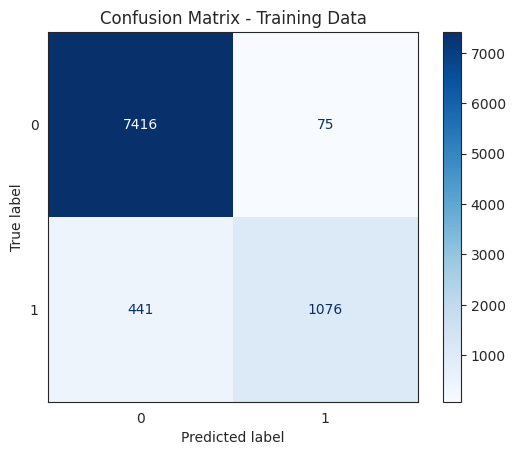

In [ ]:
log_acc = accuracy_score(y_train, SVM_model1_ytrain_pred)

print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_train, SVM_model1_ytrain_pred))

cm = confusion_matrix(y_train, SVM_model1_ytrain_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - Training Data")
plt.show()


Model Performance:
Logistic Regression Accuracy: 0.9352

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      1873
           1       0.91      0.69      0.78       379

    accuracy                           0.94      2252
   macro avg       0.92      0.84      0.87      2252
weighted avg       0.93      0.94      0.93      2252



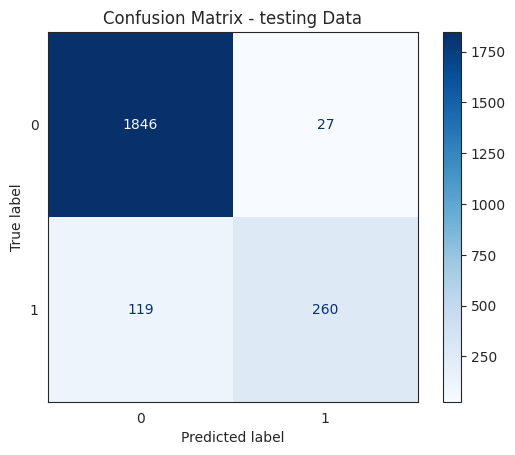

In [ ]:
log_acc = accuracy_score(y_test, SVM_model1_ytest_pred)

print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_test, SVM_model1_ytest_pred))

cm = confusion_matrix(y_test, SVM_model1_ytest_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - testing Data")
plt.show()

SVM_model2: Hyperparameter tuned model

In [ ]:
grid={'C':[1,2,3,4,5,6,7,8,9],
      'kernel':['linear','poly','rbf','sigmoid'],
      'degree':[3,4,5],
      'gamma':['scale','auto'],
      'class_weight':['balanced','None'],
      'tol':[0.001,0.0001]
     }

In [ ]:
model = svm.SVC(max_iter=2000,random_state=1)

grid_search = GridSearchCV(estimator = model, param_grid = grid, cv = 3,n_jobs=-1,scoring='f1')

grid_search.fit(X_train, y_train)

print(grid_search.best_params_,'\n')
print(grid_search.best_estimator_)

In [ ]:
SVM_model2 = svm.SVC(C=9, class_weight='balanced', degree=5, gamma='scale', kernel='poly', tol=0.001, random_state=1, probability=True)
SVM_model2 = SVM_model2.fit(X_train,y_train)

In [ ]:
### Predicting on train and test dataset
SVM_model2_ytrain_pred = SVM_model2.predict(X_train)
SVM_model2_ytest_pred = SVM_model2.predict(X_test)

## Predicting probabilities on train dataset
SVM_model2_trainprobs = SVM_model2.predict_proba(X_train)
# # keep probabilities for the positive outcome only
SVM_model2_trainprobs = SVM_model2_trainprobs[:, 1]

## Predicting probabilities on test dataset
SVM_model2_testprobs = SVM_model2.predict_proba(X_test)
# # keep probabilities for the positive outcome only
SVM_model2_testprobs = SVM_model2_testprobs[:, 1]

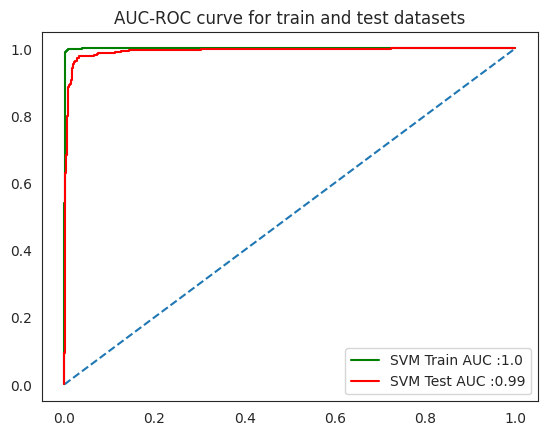

In [ ]:
# # calculate roc AUC and plot roc curve
train_auc = round(roc_auc_score(y_train, SVM_model2_trainprobs),2)
test_auc = round(roc_auc_score(y_test, SVM_model2_testprobs),2)
train_label_SVM = 'SVM Train AUC :' + str(train_auc)
test_label_SVM = 'SVM Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(y_train, SVM_model2_trainprobs)
fpr_test_SVM, tpr_test_SVM, thresholds_test_SVM = roc_curve(y_test, SVM_model2_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label_SVM)
plt.plot(fpr_test_SVM, tpr_test_SVM, color='red', label=test_label_SVM)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();


Model Performance:
Logistic Regression Accuracy: 0.9915

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      7491
           1       0.95      1.00      0.98      1517

    accuracy                           0.99      9008
   macro avg       0.98      0.99      0.99      9008
weighted avg       0.99      0.99      0.99      9008



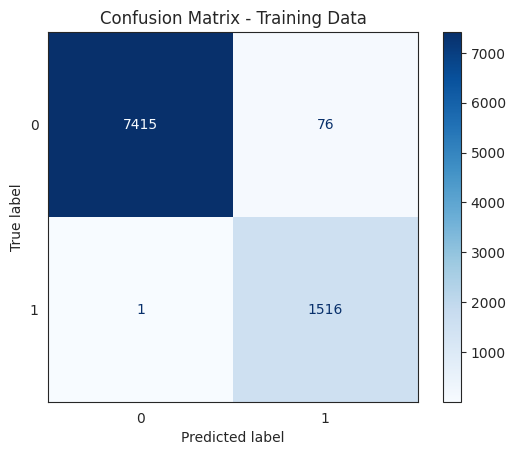

In [ ]:
log_acc = accuracy_score(y_train, SVM_model2_ytrain_pred)

print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_train, SVM_model2_ytrain_pred))

cm = confusion_matrix(y_train, SVM_model2_ytrain_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - Training Data")
plt.show()



Model Performance:
Logistic Regression Accuracy: 0.9765

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      1873
           1       0.91      0.96      0.93       379

    accuracy                           0.98      2252
   macro avg       0.95      0.97      0.96      2252
weighted avg       0.98      0.98      0.98      2252



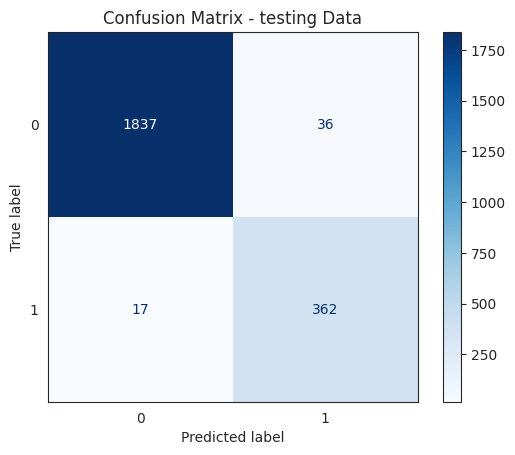

In [ ]:
log_acc = accuracy_score(y_test, SVM_model2_ytest_pred)

print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_test, SVM_model2_ytest_pred))

cm = confusion_matrix(y_test, SVM_model2_ytest_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - testing Data")
plt.show()

Feature importance for the best SVM model

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
imps = permutation_importance(SVM_model2, X_test, y_test)

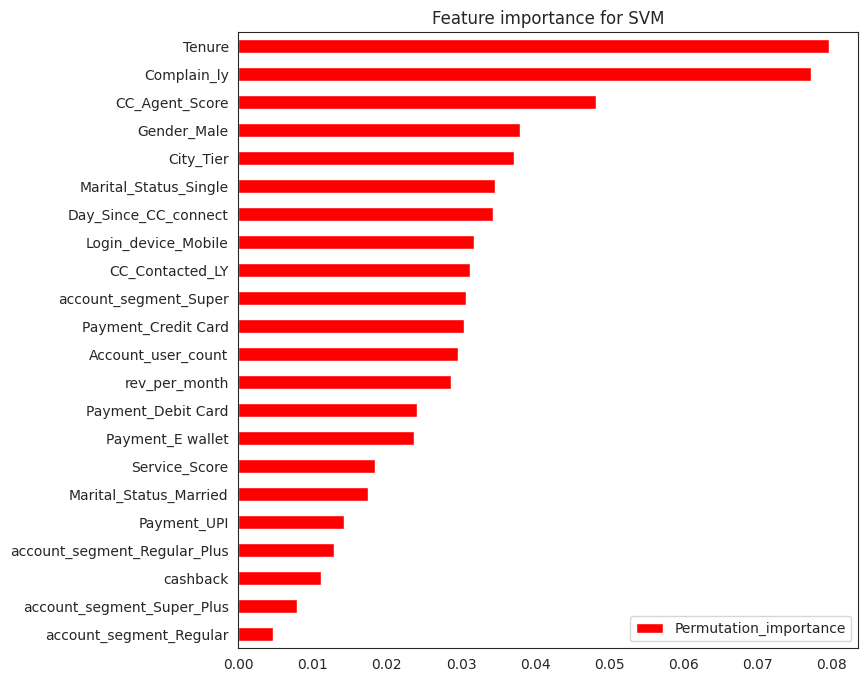

In [ ]:
imp_df = pd.DataFrame(imps.importances_mean, columns=['Permutation_importance'], index = X.columns)
## plotting graph
imp_df = imp_df.sort_values(by='Permutation_importance')
my_colors = ['red','green','blue','cyan','magenta','yellow']
imp_df.plot(kind='barh', color = my_colors, figsize=(8,8))
plt.title("Feature importance for SVM")
plt.show();

Random Forest

RF_model1: Base model without outliers and scaled data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Build a RandomForestCassifier and fit it on the training data
RF_model1 = RandomForestClassifier(random_state=123, oob_score=True)
RF_model1 = RF_model1.fit(X_train, y_train)

In [ ]:
RF_model1.oob_score_

0.9761323268206039

In [ ]:
### Predicting on train and test dataset
RF_model1_ytrain_pred = RF_model1.predict(X_train)
RF_model1_ytest_pred = RF_model1.predict(X_test)

## Predicting probabilities on train dataset
RF_model1_trainprobs = RF_model1.predict_proba(X_train)
# # keep probabilities for the positive outcome only
RF_model1_trainprobs = RF_model1_trainprobs[:, 1]

## Predicting probabilities on test dataset
RF_model1_testprobs = RF_model1.predict_proba(X_test)
# # keep probabilities for the positive outcome only
RF_model1_testprobs = RF_model1_testprobs[:, 1]

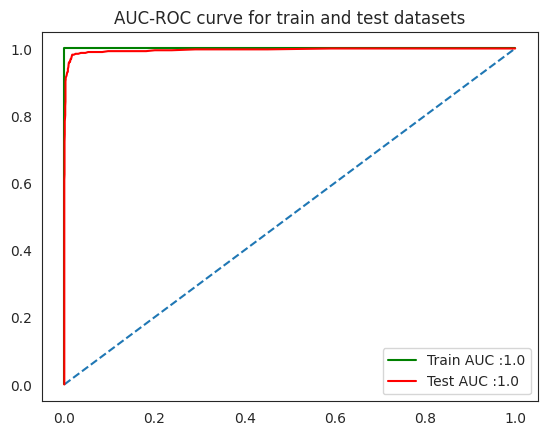

In [ ]:
# # calculate AUC and plot roc curve
train_auc = round(roc_auc_score(y_train, RF_model1_trainprobs),2)
test_auc = round(roc_auc_score(y_test, RF_model1_testprobs),2)
train_label = 'Train AUC :' + str(train_auc)
test_label = 'Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(y_train, RF_model1_trainprobs)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, RF_model1_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label)
plt.plot(fpr_test, tpr_test, color='red', label=test_label)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();



Model Performance:
Logistic Regression Accuracy: 1.0000

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      7491
           1       1.00      1.00      1.00      1517

    accuracy                           1.00      9008
   macro avg       1.00      1.00      1.00      9008
weighted avg       1.00      1.00      1.00      9008



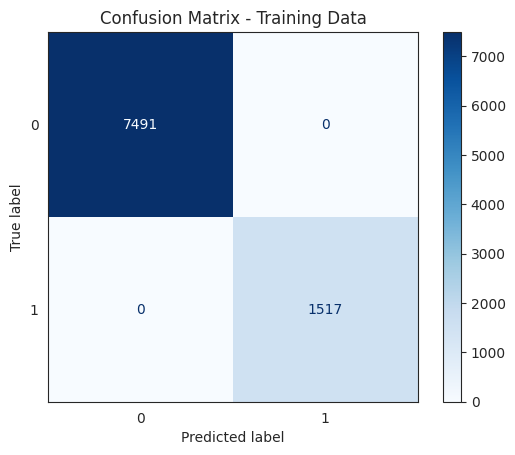

In [ ]:
log_acc = accuracy_score(y_train, RF_model1_ytrain_pred)

print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_train, RF_model1_ytrain_pred))

cm = confusion_matrix(y_train, RF_model1_ytrain_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - Training Data")
plt.show()



Model Performance:
Logistic Regression Accuracy: 0.9818

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1873
           1       0.98      0.91      0.94       379

    accuracy                           0.98      2252
   macro avg       0.98      0.95      0.97      2252
weighted avg       0.98      0.98      0.98      2252



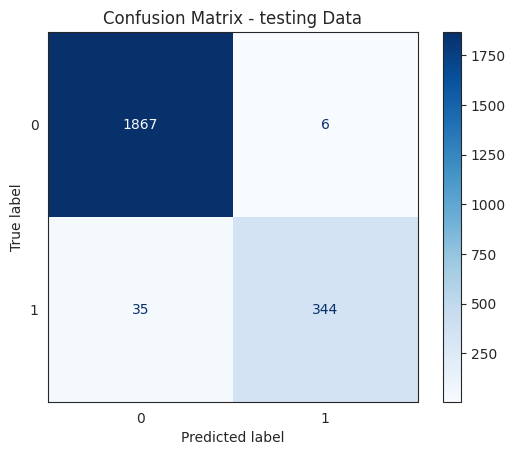

In [ ]:
log_acc = accuracy_score(y_test, RF_model1_ytest_pred)

print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(y_test, RF_model1_ytest_pred))

cm = confusion_matrix(y_test, RF_model1_ytest_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - testing Data")
plt.show()

In [ ]:
pd.DataFrame(RF_model1.feature_importances_, index=X.columns, columns=['Feature importance'])

,Feature importance
Tenure,0.252371
City_Tier,0.029624
CC_Contacted_LY,0.078854
Service_Score,0.025142
Account_user_count,0.043513
CC_Agent_Score,0.062302
rev_per_month,0.062984
Complain_ly,0.069968
Day_Since_CC_connect,0.078437
cashback,0.091197


RF_model2: Base model with outliers and unscaled data

In [ ]:
X_ot = df_outlier.drop('Churn',axis=1)
y_ot = df_outlier['Churn']

In [ ]:
# Split X and y into training and test set in 70:30 ratio
Xot_train, Xot_test, yot_train, yot_test = train_test_split(X_ot, y_ot, test_size=0.30 , random_state=1, stratify=y_ot)

In [ ]:
#Build a RandomForestCassifier andfit it on the training data
RF_model2 = RandomForestClassifier(random_state=123, oob_score=True)
RF_model2 = RF_model2.fit(Xot_train, yot_train)

In [ ]:
### Predicting on train and test dataset
RF_model2_ytrain_pred = RF_model2.predict(Xot_train)
RF_model2_ytest_pred = RF_model2.predict(Xot_test)

## Predicting probabilities on train dataset
RF_model2_trainprobs = RF_model2.predict_proba(Xot_train)
# # keep probabilities for the positive outcome only
RF_model2_trainprobs = RF_model2_trainprobs[:, 1]

## Predicting probabilities on test dataset
RF_model2_testprobs = RF_model2.predict_proba(Xot_test)
# # keep probabilities for the positive outcome only
RF_model2_testprobs = RF_model2_testprobs[:, 1]

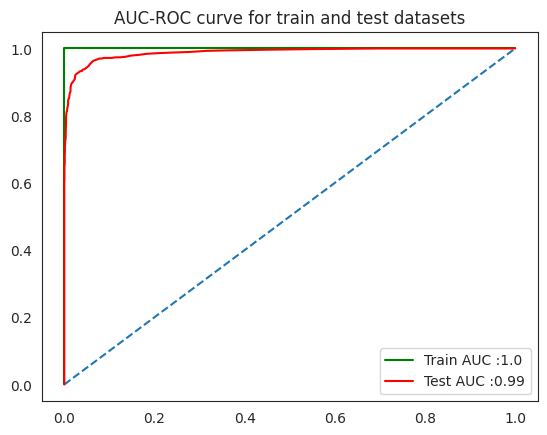

In [ ]:
# # calculate AUC and plot roc curve
train_auc = round(roc_auc_score(yot_train, RF_model2_trainprobs),2)
test_auc = round(roc_auc_score(yot_test, RF_model2_testprobs),2)
train_label = 'Train AUC :' + str(train_auc)
test_label = 'Test AUC :' + str(test_auc)


fpr_train, tpr_train, thresholds_train = roc_curve(yot_train, RF_model2_trainprobs)
fpr_test, tpr_test, thresholds_test = roc_curve(yot_test, RF_model2_testprobs)

# # plot the roc curve for the model
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr_train, tpr_train, color='green',label=train_label)
plt.plot(fpr_test, tpr_test, color='red', label=test_label)plt.plot(fpr_test_rf, tpr_test_rf, color='red', label=test_label_rf)
plt.legend(loc='best')
plt.title("AUC-ROC curve for train and test datasets")
plt.show();


Model Performance:
Random Forest Accuracy: 1.0000

Classification Reports:

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6555
           1       1.00      1.00      1.00      1327

    accuracy                           1.00      7882
   macro avg       1.00      1.00      1.00      7882
weighted avg       1.00      1.00      1.00      7882



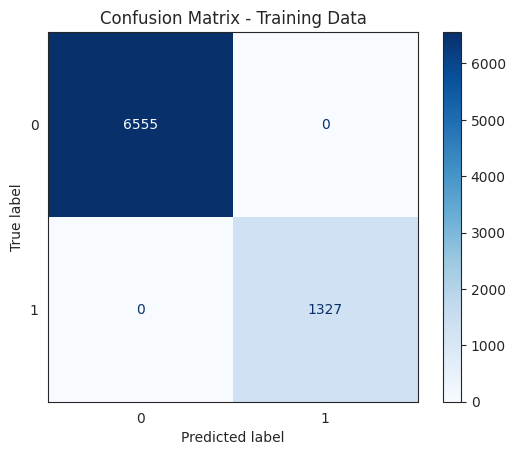

In [ ]:
log_acc = accuracy_score(yot_train, RF_model2_ytrain_pred)

print("\nModel Performance:")
print(f"Random Forest Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nRandom Forest:\n", classification_report(yot_train, RF_model2_ytrain_pred))

cm = confusion_matrix(yot_train, RF_model2_ytrain_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - Training Data")
plt.show()


Model Performance:
Logistic Regression Accuracy: 0.9645

Classification Reports:

Logistic Regression:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      2809
           1       0.96      0.83      0.89       569

    accuracy                           0.96      3378
   macro avg       0.96      0.91      0.93      3378
weighted avg       0.96      0.96      0.96      3378



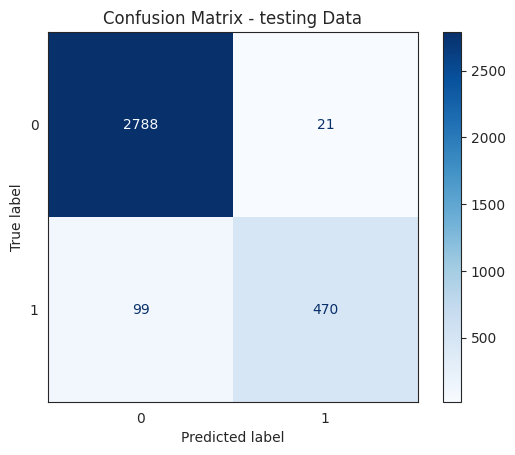

In [ ]:
log_acc = accuracy_score(yot_test, RF_model2_ytest_pred)

print("\nModel Performance:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Reports:")
print("\nLogistic Regression:\n", classification_report(yot_test, RF_model2_ytest_pred))

cm = confusion_matrix(yot_test, RF_model2_ytest_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can change the colormap if needed
plt.title("Confusion Matrix - testing Data")
plt.show()

Feature importances for Random Forest Model

In [ ]:
imp_df = pd.DataFrame(RF_model1.feature_importances_, index=X.columns, columns=['Feature Importance'])
imp_df

,Feature Importance
Tenure,0.252371
City_Tier,0.029624
CC_Contacted_LY,0.078854
Service_Score,0.025142
Account_user_count,0.043513
CC_Agent_Score,0.062302
rev_per_month,0.062984
Complain_ly,0.069968
Day_Since_CC_connect,0.078437
cashback,0.091197


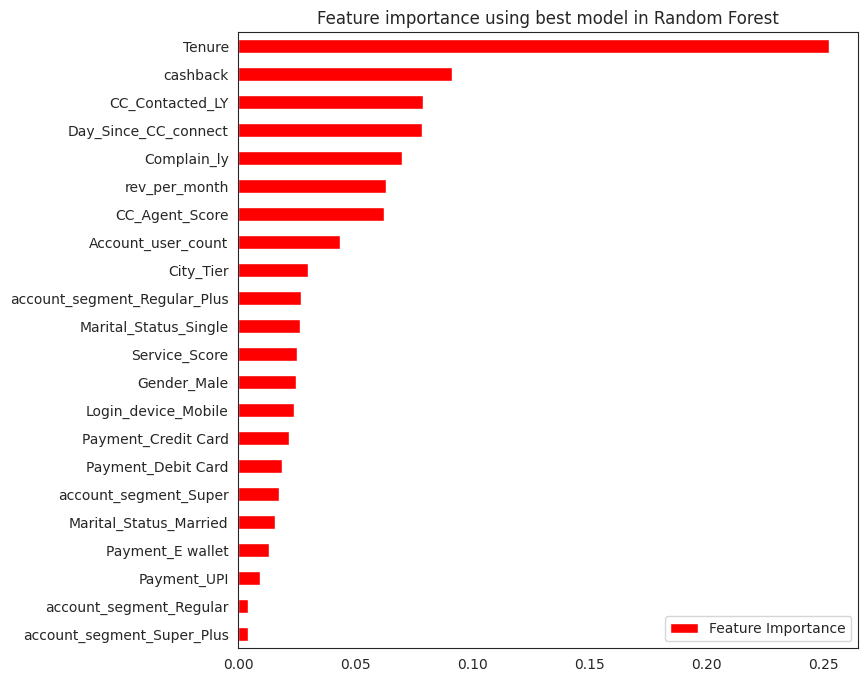

In [ ]:
## plotting graph
imp_df = imp_df.sort_values(by='Feature Importance')
my_colors = ['red','green','blue','black','orange','cyan','magenta','brown']
imp_df.plot(kind='barh', color = my_colors, figsize=(8,8))
plt.title("Feature importance using best model in Random Forest")
plt.show();

Comprehensive ROC plot for all models

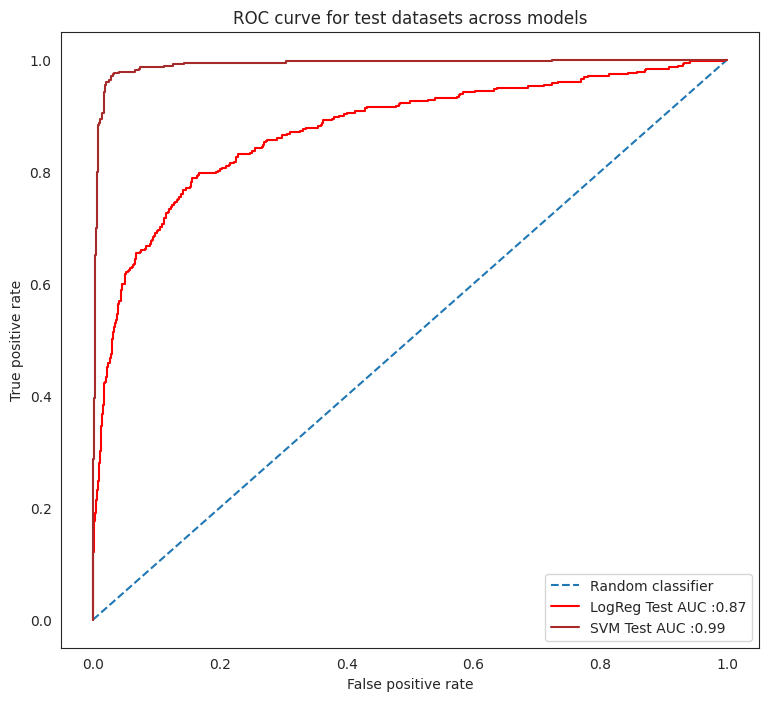

In [ ]:
# # plot the roc curve for the model
plt.figure(figsize=(9,8))
plt.plot([0, 1], [0, 1], linestyle='--',label='Random classifier')
plt.plot(fpr_test_LR, tpr_test_LR, color='red', label=test_label_LR)
plt.plot(fpr_test_SVM, tpr_test_SVM, color='brown', label=test_label_SVM)
plt.legend(loc='best')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve for test datasets across models")
plt.show();